In [1]:
# Imports
import sys
sys.path.insert(1, '/users/gj23442/analysis/pion-argon-xs-analysis/analysis/')
import importlib
import numpy as np
import awkward as ak
import pandas as pd
# from particle import Particle
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
#import matplotlib as mpl
#from mpl_toolkits.mplot3d import Axes3D
from python.analysis import BeamParticleSelection, Master, SelectionTools, vector
#from python.analysis import SelectionEvaluation as seval
from python.analysis import Tags, Plots
from python.pdhd_MC import beam_selection
importlib.reload(Master)
importlib.reload(BeamParticleSelection)
importlib.reload(SelectionTools)
importlib.reload(Tags)
importlib.reload(beam_selection)
from python.analysis.PFOSelection import Median

2026-07-22 09:54:23.922720: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [19]:
## Full dataset col plane fixed for michel score but interesting volume selection retained

filename = "/storage/2/gj23442/ana_pdhd_prod_beam_test_v5__gen_g4_IonScintPDExt_PDInt.root"
events_old = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [20]:
true_beam_mask = beam_selection.BeamTriggerSelection(events_old, return_property=True)
mask = true_beam_mask[0]
bi_evts = events_old.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
track_selected_evts = track_evts.Filter([mask], [mask], returnCopy=True)

median = Median(track_selected_evts.recoParticles.beam_dEdX_noSCE)
mask = median < 3.0
pid_evts_old = track_selected_evts.Filter([mask], [mask], returnCopy=True)

In [21]:
purity = ak.sum(beam_selection.signal_mask(pid_evts_old)) / len(beam_selection.signal_mask(pid_evts_old))
print(f"Purity after PID selection: {purity:.2%}")

eff_bt = ak.sum(beam_selection.signal_mask(pid_evts_old)) / ak.sum(beam_selection.signal_mask(events_old))
eff_true = ak.sum(beam_selection.true_signal_mask(pid_evts_old)) / ak.sum(beam_selection.true_signal_mask(events_old))
print(f"Efficiency of the PID selection from backtracking: {eff_bt:.2%}")
print(f"Efficiency of the PID selection from truth info: {eff_true:.2%}")

Purity after PID selection: 64.69%
Efficiency of the PID selection from backtracking: 45.49%
Efficiency of the PID selection from truth info: 32.07%


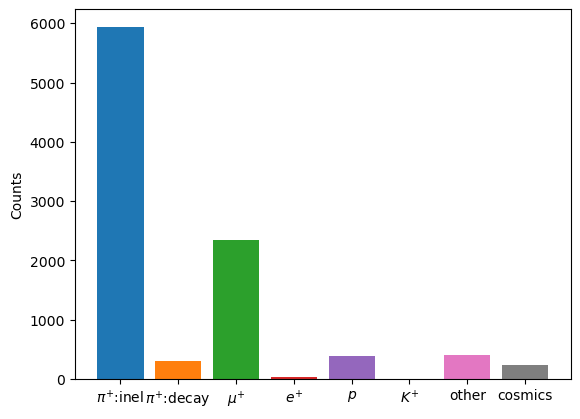

In [22]:
tags = Tags.GenerateBeamCandidateTags(pid_evts_old)
counts = ak.sum(tags.mask.values, axis=-1)
#counts = counts/np.sum(counts)
plt.bar(tags.name.values, counts, color= tags.colour.values)
plt.ylabel("Counts")
plt.show()

In [23]:
filename = "/storage/2/gj23442/ana_pdhd_prod_beam_test_v4_gen_g4_IonScintPDExt_PDInt.root"
events = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [24]:
true_beam_mask = beam_selection.BeamTriggerSelection(events, return_property=True)
mask = true_beam_mask[0]
bi_evts = events.Filter([mask], [mask], returnCopy=True)
print(len(bi_evts.event_index))

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)
print(len(bv_evts.event_index))

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)
print(len(track_evts.event_index))

_, mask = beam_selection.BeamQualitySelection(track_evts)
track_selected_evts = track_evts.Filter([mask], [mask], returnCopy=True)
print(len(track_selected_evts.event_index))

median = Median(track_selected_evts.recoParticles.beam_dEdX_noSCE)
mask = median < 3.0
pid_evts = track_selected_evts.Filter([mask], [mask], returnCopy=True)
print(len(pid_evts.event_index))

28868
16414
13917
10713
9604


In [14]:
track_selected_evts.event_index, pid_evts.event_index

(<Array [0, 7, 9, ... 180695, 180709, 180733] type='10713 * int64'>,
 <Array [0, 7, 9, ... 180683, 180695, 180709] type='9604 * int64'>)

0


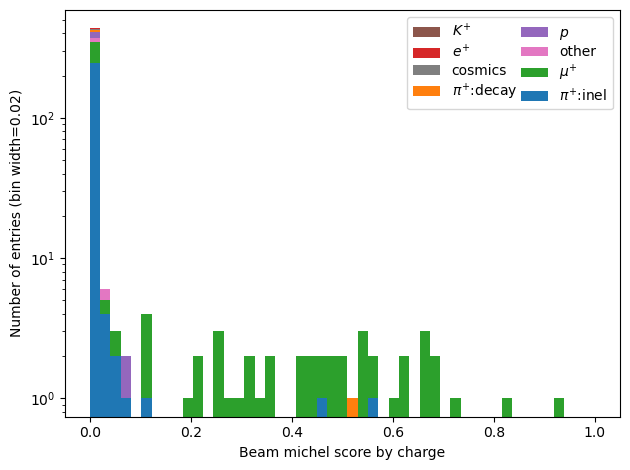

In [27]:
tags = Tags.GenerateBeamCandidateTags(pid_evts_old)
bins = np.linspace(0, 1, 50)
print(ak.sum(pid_evts_old.recoParticles.beam_michelScore_by_charge==0))
Plots.PlotTagged(pid_evts_old.recoParticles.beam_michelScore_by_charge, tags, bins=bins, y_scale="log", x_label="Beam michel score by charge")

In [32]:
np.unique(pid_evts.recoParticles.beam_michelScore_by_charge, return_counts=True)

(array([-9.99000000e+02,  1.15600721e-11,  1.22303664e-11, ...,
         9.99687466e-01,  9.99766112e-01,  9.99785168e-01]),
 array([3925,    1,    1, ...,    1,    1,    1]))

0


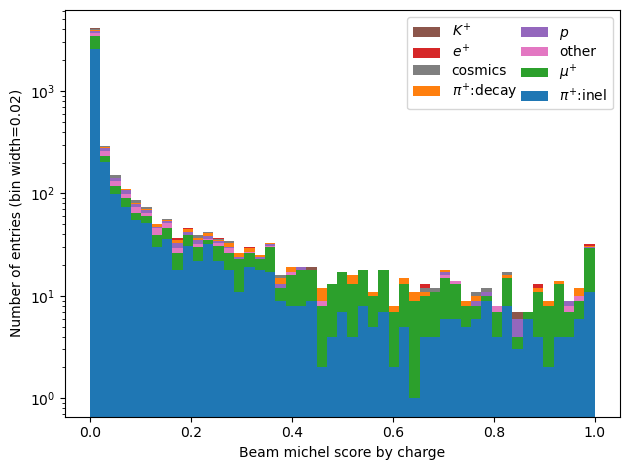

In [28]:
tags = Tags.GenerateBeamCandidateTags(pid_evts)
bins = np.linspace(0, 1, 50)
print(ak.sum(pid_evts.recoParticles.beam_michelScore_by_charge==0))
Plots.PlotTagged(pid_evts.recoParticles.beam_michelScore_by_charge, tags, bins=bins, y_scale="log", x_label="Beam michel score by charge")

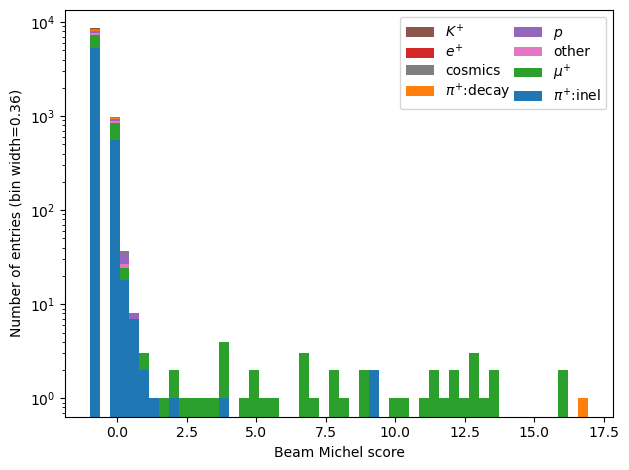

In [35]:
tags = Tags.GenerateBeamCandidateTags(pid_evts_old)
Plots.PlotTagged(pid_evts_old.recoParticles.beam_michelScore, tags, bins=50, y_scale="log", x_label="Beam Michel score")

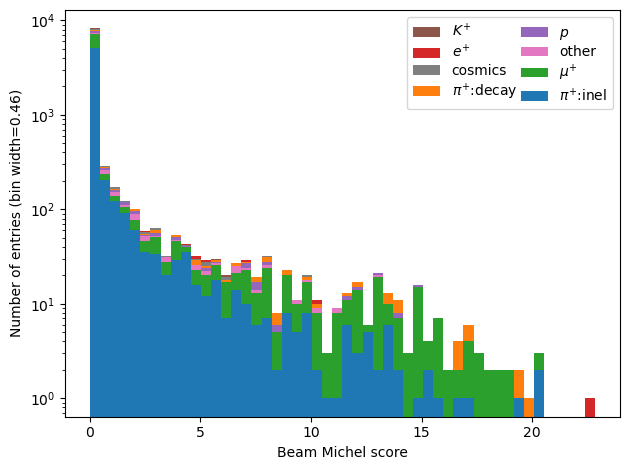

In [36]:
tags = Tags.GenerateBeamCandidateTags(pid_evts)
Plots.PlotTagged(pid_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale="log", x_label="Beam Michel score")

In [45]:
def plot_FOM(evts, param, range):

    def signal_mask(evts):
        return evts.trueParticlesBT.beam_pdg == -13

    purity, efficiency = [], []

    for cut in range:
        mask = param < cut
        cut_evts = evts.Filter([mask], [mask], returnCopy=True)
        p = ak.sum(signal_mask(cut_evts)) / len(signal_mask(cut_evts))
        e = ak.sum(signal_mask(cut_evts)) / ak.sum(signal_mask(evts))
        purity.append(p)
        efficiency.append(e)
    
    plt.figure(figsize=(8, 6)) 
    plt.plot(range, purity, marker='o', label="Purity")
    plt.plot(range, efficiency, marker='o', label="Efficiency")
    plt.plot(range, np.array(purity) * np.array(efficiency), marker='o', label="Efficiency * Purity")

    return purity, efficiency

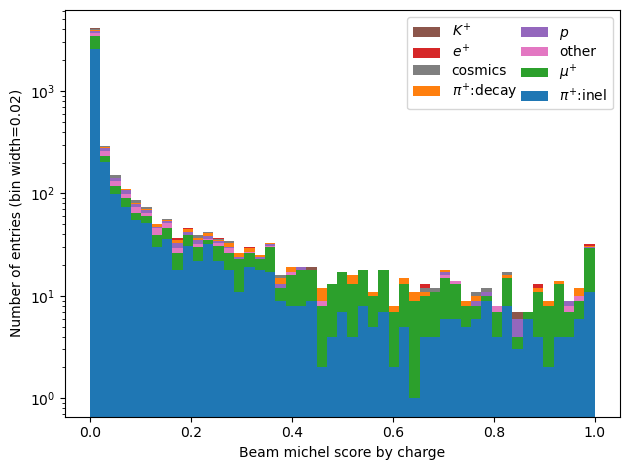

In [52]:
tags = Tags.GenerateBeamCandidateTags(pid_evts)
bins = np.linspace(0, 1, 50)
Plots.PlotTagged(pid_evts.recoParticles.beam_michelScore_by_charge, tags, bins=bins, y_scale="log", x_label="Beam michel score by charge")

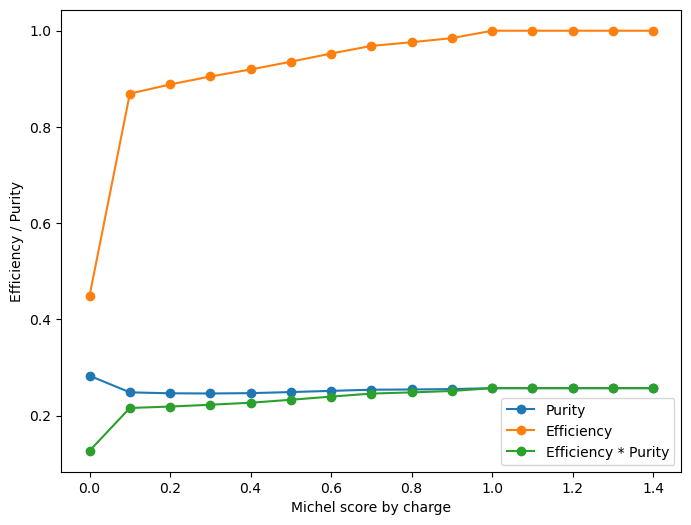

In [47]:
p, e = plot_FOM(pid_evts, pid_evts.recoParticles.beam_michelScore_by_charge, np.arange(0, 1.5, 0.1))
plt.xlabel("Michel score by charge")
plt.ylabel("Efficiency / Purity")
plt.legend()
plt.show()

In [ ]:
tags = Tags.GenerateBeamCandidateTags(pid_evts)
Plots.PlotTagged(pid_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale="log", x_label="Beam Michel score")

/tmp/ipykernel_952779/4294772897.py:11: RuntimeWarning: invalid value encountered in scalar divide
  p = ak.sum(signal_mask(cut_evts)) / len(signal_mask(cut_evts))


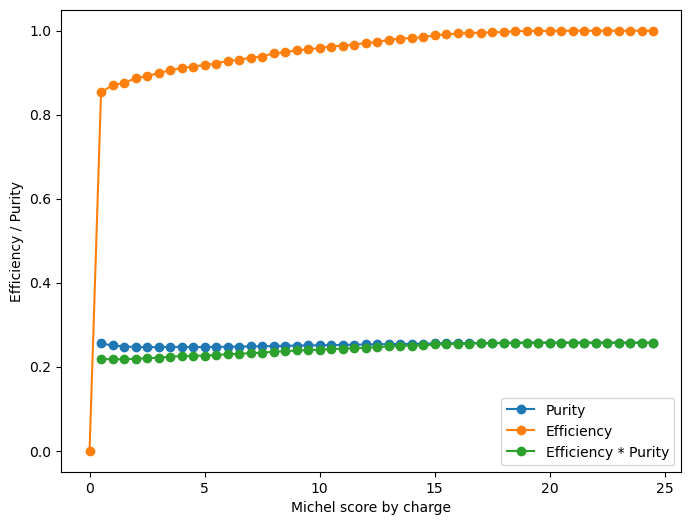

In [66]:
p, e = plot_FOM(pid_evts, pid_evts.recoParticles.beam_michelScore, np.arange(0, 25, 0.5))
plt.xlabel("Michel score by charge")
plt.ylabel("Efficiency / Purity")
plt.legend()
plt.show()

In [67]:
np.arange(0, 25, 0.5)

array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
        5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
       11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ,
       16.5, 17. , 17.5, 18. , 18.5, 19. , 19.5, 20. , 20.5, 21. , 21.5,
       22. , 22.5, 23. , 23.5, 24. , 24.5])

In [68]:
np.array(p)*np.array(e)

array([       nan, 0.21822948, 0.21800541, 0.21738414, 0.21911888,
       0.21991836, 0.22176376, 0.22372742, 0.22544042, 0.2257555 ,
       0.22664127, 0.22767503, 0.22996206, 0.23054241, 0.23250674,
       0.23316371, 0.2360895 , 0.23672142, 0.23877042, 0.23945407,
       0.24084852, 0.24209248, 0.24313564, 0.24377183, 0.24568297,
       0.24624307, 0.24864825, 0.24951668, 0.25023201, 0.25069287,
       0.2529827 , 0.25365199, 0.25471007, 0.25504534, 0.2555085 ,
       0.25563626, 0.25617973, 0.25690502, 0.25726794, 0.25724113,
       0.25718754, 0.25731542, 0.25731542, 0.25731542, 0.25731542,
       0.25731542, 0.25728863, 0.25728863, 0.25728863, 0.25728863])

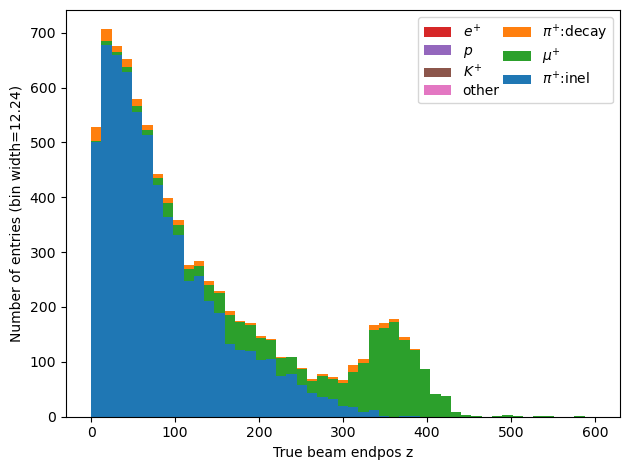

In [60]:
tags = Tags.GenerateTrueBeamParticleTags(pid_evts)
Plots.PlotTagged(pid_evts.trueParticles.endPos.z[:, 0], tags, bins=np.linspace(0, 600, 50), y_scale="linear", x_label="True beam endpos z")
plt.show()

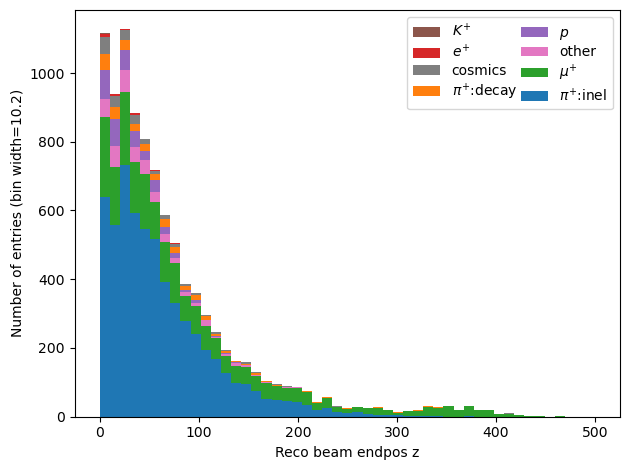

In [62]:
tags = Tags.GenerateBeamCandidateTags(pid_evts)
Plots.PlotTagged(pid_evts.recoParticles.beam_endPos_SCE.z, tags, bins=np.linspace(0, 500, 50), y_scale="linear", x_label="Reco beam endpos z")
plt.show()

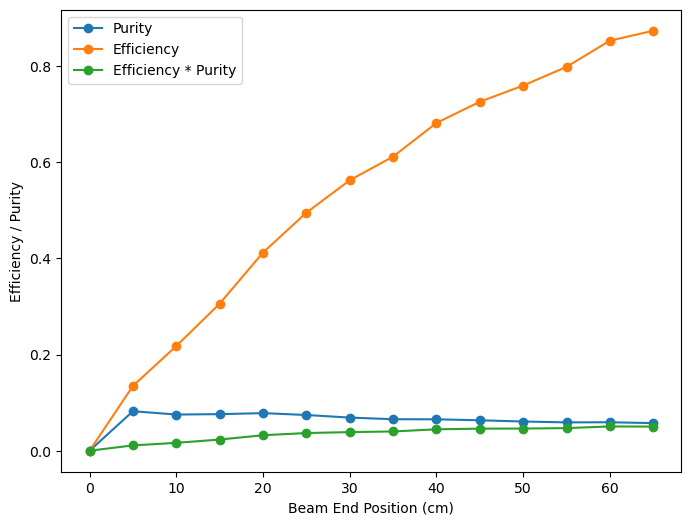

In [59]:
p, e = plot_FOM(pid_evts, pid_evts.recoParticles.beam_endPos_SCE.z, np.arange(0, 70, 5))
plt.xlabel("Beam End Position (cm)")
plt.ylabel("Efficiency / Purity")
plt.legend()
plt.show()

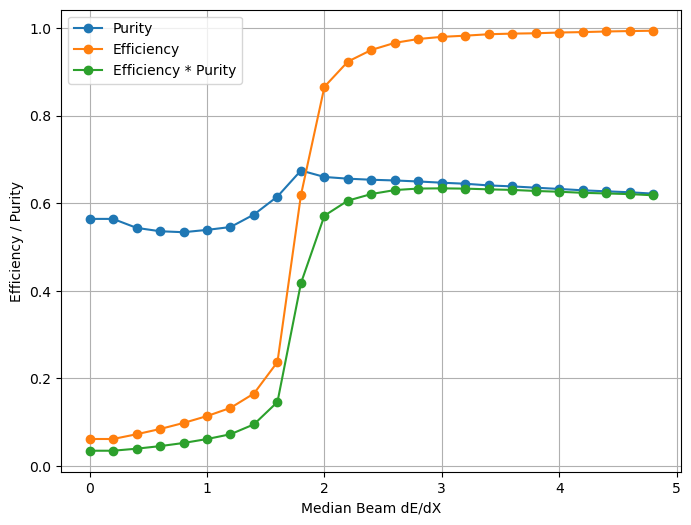

In [39]:
median = Median(track_selected_evts.recoParticles.beam_dEdX_noSCE)
plot_FOM(track_selected_evts, median, np.arange(0, 5, 0.2))
plt.xlabel("Median Beam dE/dX")
plt.ylabel("Efficiency / Purity")
plt.grid(True)
plt.legend()
plt.show()

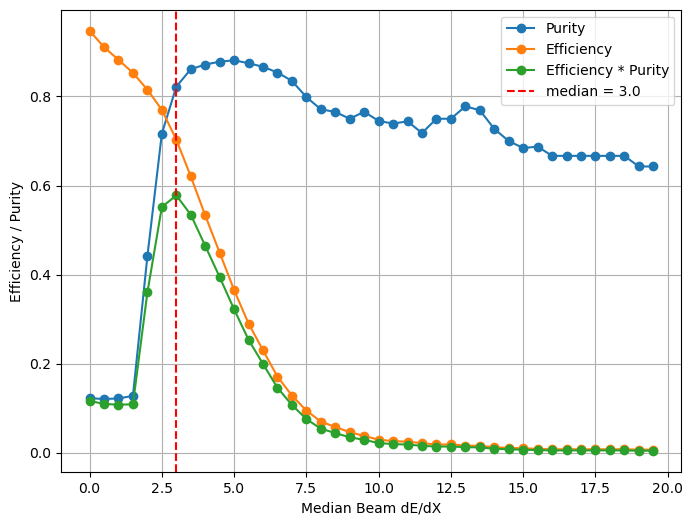

In [56]:
median = Median(track_selected_evts.recoParticles.beam_dEdX_noSCE)
p, e = plot_FOM(track_selected_evts, median, np.arange(0, 20, 0.5))
plt.xlabel("Median Beam dE/dX")
plt.ylabel("Efficiency / Purity")
plt.grid(True)
plt.axvline(x=3.0, color='r', linestyle='--', label='median = 3.0')
plt.legend()
plt.show()

In [61]:
pid_evts.event_index

<Array [11, 23, 38, ... 181376, 181384, 181389] type='9637 * int64'>

In [ ]:
def purity_efficiency(evts, ini_evts):

    def signal_mask(evts):
        return evts.trueParticlesBT.beam_pdg == 211

    purity = ak.sum(signal_mask(evts)) / len(signal_mask(evts))
    efficiency = ak.sum(signal_mask(evts)) / ak.sum(signal_mask(ini_evts))
    return purity, efficiency

In [ ]:
rng = np.arange(2, 3.5, 0.1)
print(rng)
purity, eff = [], []
for cut in rng:
    median = Median(track_selected_evts.recoParticles.beam_dEdX_noSCE)
    mask = median < cut
    dedx_evts = track_selected_evts.Filter([mask], [mask], returnCopy=True)
    p, e = purity_efficiency(dedx_evts, track_selected_evts)
    purity.append(p)
    eff.append(e)

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(rng, purity, marker="o", label="Purity")
plt.plot(rng, eff, marker="o", label="Efficiency")
plt.plot(rng, np.array(purity)*np.array(eff), marker="o", label="Purity x Efficiency")
plt.xlabel("Median dE/dX")
plt.ylabel("Purity / Efficiency")
plt.title("Purity and Efficiency for dE/dX Cut")
plt.legend()
plt.grid()
plt.show()

693 10749


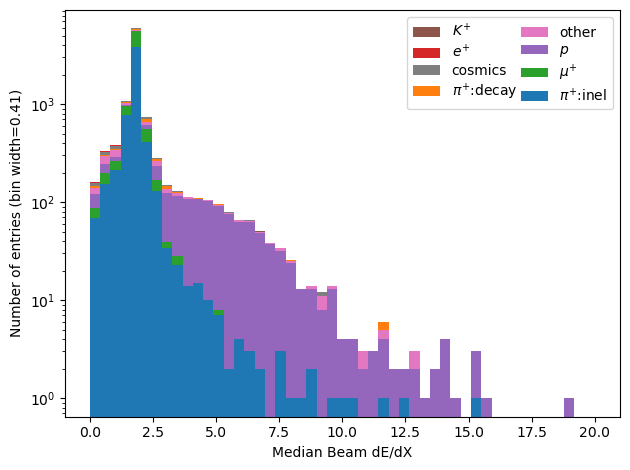

In [13]:
from python.analysis.PFOSelection import Median
median = Median(track_selected_evts.recoParticles.beam_dEdX_noSCE)
print(ak.sum(median==-999), len(median))
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(median, tags, bins=np.linspace(0, 20, 50), y_scale="log", x_label="Median Beam dE/dX")
plt.show()

In [44]:
def proton_p_e(evts, ini_evts):

    def signal_mask(evts):
        return evts.trueParticlesBT.beam_pdg == 2212

    purity = ak.sum(signal_mask(evts)) / len(signal_mask(evts))
    efficiency = ak.sum(signal_mask(evts)) / ak.sum(signal_mask(ini_evts))
    return purity, efficiency

In [45]:
rng = np.arange(0, 20, 0.5)
print(rng)
purity, eff = [], []
for cut in rng:
    median = Median(track_selected_evts.recoParticles.beam_dEdX_noSCE)
    mask = median > cut
    dedx_evts = track_selected_evts.Filter([mask], [mask], returnCopy=True)
    p, e = proton_p_e(dedx_evts, track_selected_evts)
    purity.append(p)
    eff.append(e)

[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5
 14.  14.5 15.  15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5]


In [46]:
np.array(purity)*np.array(eff)

array([0.1161055 , 0.10981169, 0.10759164, 0.10886793, 0.35982835,
       0.55173228, 0.57788877, 0.5346433 , 0.46468215, 0.39451243,
       0.32199943, 0.25366589, 0.19933333, 0.14581065, 0.10726538,
       0.07556943, 0.05398305, 0.04415228, 0.03461538, 0.02885817,
       0.02177979, 0.0193311 , 0.01831843, 0.01546351, 0.01384615,
       0.01384615, 0.0125641 , 0.01183432, 0.00895105, 0.00753846,
       0.00684211, 0.00581731, 0.00512821, 0.00512821, 0.00512821,
       0.00512821, 0.00512821, 0.00512821, 0.00445055, 0.00445055])

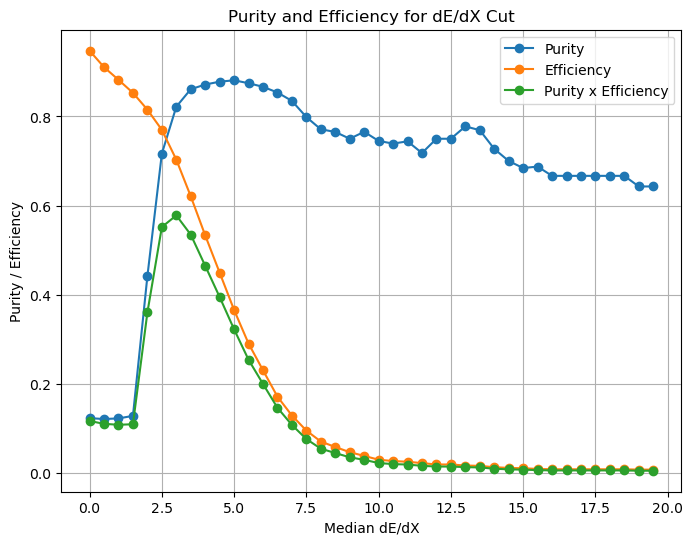

In [47]:
plt.figure(figsize=(8, 6))
plt.plot(rng, purity, marker="o", label="Purity")
plt.plot(rng, eff, marker="o", label="Efficiency")
plt.plot(rng, np.array(purity)*np.array(eff), marker="o", label="Purity x Efficiency")
plt.xlabel("Median dE/dX")
plt.ylabel("Purity / Efficiency")
plt.title("Purity and Efficiency for dE/dX Cut")
plt.legend()
plt.grid()
plt.show()

In [24]:
def purity_efficiency(evts, ini_evts):

    def signal_mask(evts):
        return evts.trueParticlesBT.beam_pdg == 211

    purity = ak.sum(signal_mask(evts)) / len(signal_mask(evts))
    efficiency = ak.sum(signal_mask(evts)) / ak.sum(signal_mask(ini_evts))
    return purity, efficiency

In [49]:
rng = np.arange(2, 3.5, 0.1)
print(rng)
purity, eff = [], []
for cut in rng:
    median = Median(track_selected_evts.recoParticles.beam_dEdX_noSCE)
    mask = median < cut
    dedx_evts = track_selected_evts.Filter([mask], [mask], returnCopy=True)
    p, e = purity_efficiency(dedx_evts, track_selected_evts)
    purity.append(p)
    eff.append(e)

[2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4]


In [50]:
np.array(purity)*np.array(eff)

array([0.57159673, 0.59227719, 0.60593321, 0.61443515, 0.62104441,
       0.62591378, 0.63005934, 0.63193941, 0.63352792, 0.63484375,
       0.63396655, 0.63308529, 0.63335418, 0.63285199, 0.63169001])

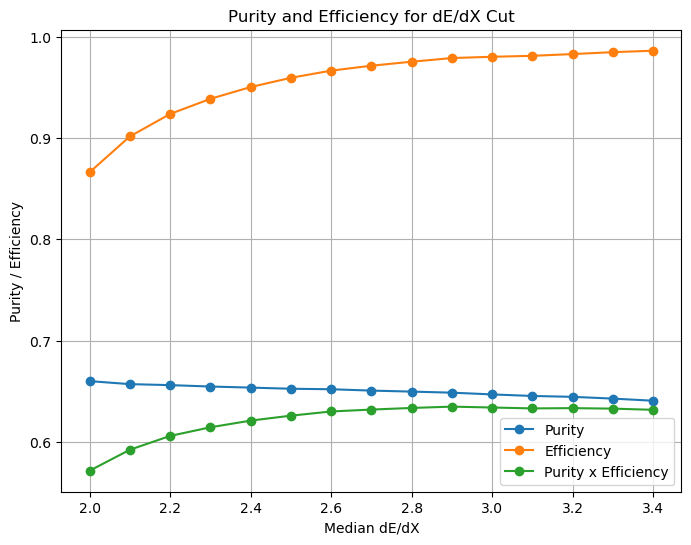

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(rng, purity, marker="o", label="Purity")
plt.plot(rng, eff, marker="o", label="Efficiency")
plt.plot(rng, np.array(purity)*np.array(eff), marker="o", label="Purity x Efficiency")
plt.xlabel("Median dE/dX")
plt.ylabel("Purity / Efficiency")
plt.title("Purity and Efficiency for dE/dX Cut")
plt.legend()
plt.grid()
plt.show()

In [14]:
median = Median(track_selected_evts.recoParticles.beam_dEdX_noSCE)
mask = median < 3.0
pid_evts = track_selected_evts.Filter([mask], [mask], returnCopy=True)
tags = Tags.GenerateBeamCandidateTags(pid_evts)
counts = ak.sum(tags.mask.values, axis=-1)
np.array(counts), np.sum(counts)

(array([5939,  295, 2343,   25,  386,    5,  405,  239]), 9637)

['$\\pi^{+}$:inel', '$\\pi^{+}$:decay', '$\\mu^{+}$', '$e^{+}$', '$p$', '$K^{+}$', 'other', 'cosmics']
[0.616, 0.0306, 0.243, 0.00259, 0.0401, 0.000519, 0.042, 0.0248]


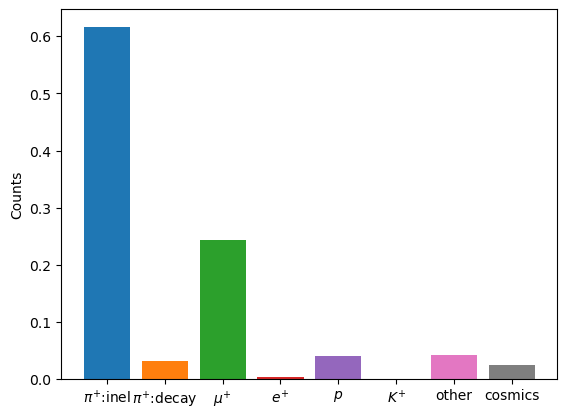

In [15]:
counts = counts/np.sum(counts)
print(tags.name.values), print(counts)
plt.bar(tags.name.values, counts, color= tags.colour.values)
plt.ylabel("Counts")
plt.show()

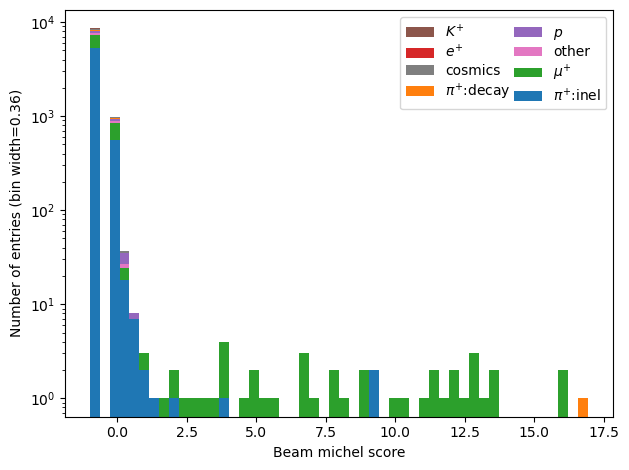

In [16]:
tags = Tags.GenerateBeamCandidateTags(pid_evts)
Plots.PlotTagged(pid_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale="log", x_label="Beam michel score")

In [17]:
michel_score = pid_evts.recoParticles.beam_michelScore

In [18]:
ak.sum(michel_score==-1)

8553

In [19]:
michel_score = pid_evts.recoParticles.beam_michelScore
mask = michel_score < 2.5

michel_selected_evts = pid_evts.Filter([mask], [mask], returnCopy=True)

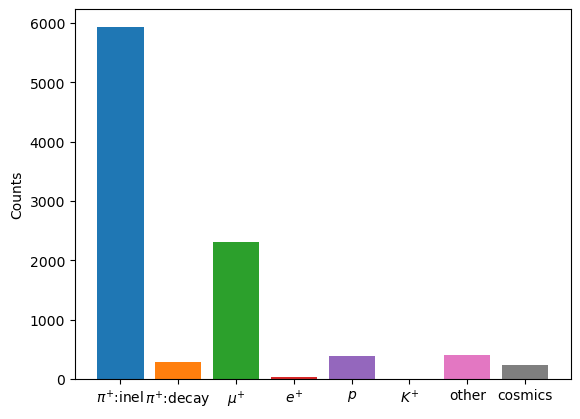

In [20]:
tags = Tags.GenerateBeamCandidateTags(michel_selected_evts)
counts = ak.sum(tags.mask.values, axis=-1)
#counts = counts/np.sum(counts)
plt.bar(tags.name.values, counts, color= tags.colour.values)
plt.ylabel("Counts")
plt.show()

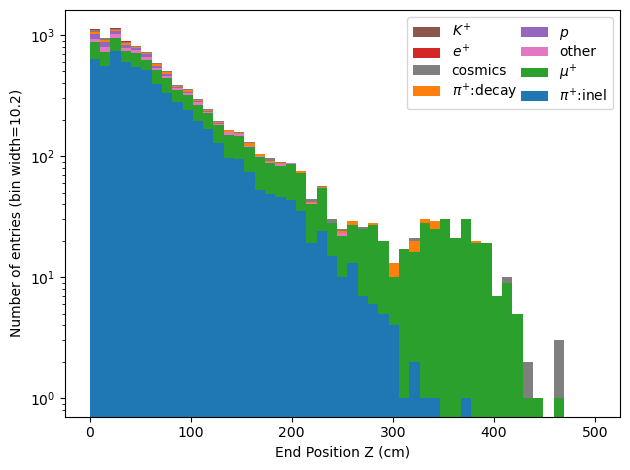

In [23]:
tags = Tags.GenerateBeamCandidateTags(pid_evts)
end_pos = pid_evts.recoParticles.beam_endPos_SCE.z
bins = np.linspace(0, 500, 50)
Plots.PlotTagged(end_pos, tags, bins=bins, y_scale='log', x_label="End Position Z (cm)")

In [31]:
## Fixed calo modules but Vplane collector config on and the config moved to fcl full dataset

filename = "/storage/2/gj23442/ana_pdhd_prod_beam_michel_volume_remove__gen_g4_IonScintPDExt_PDInt.root"
events = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [32]:
true_beam_mask = beam_selection.BeamTriggerSelection(events, return_property=True)
mask = true_beam_mask[0]
bi_evts = events.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
track_selected_evts = track_evts.Filter([mask], [mask], returnCopy=True)

median = Median(track_selected_evts.recoParticles.beam_dEdX_noSCE)
mask = median < 3.0
proton_pid_evts = track_selected_evts.Filter([mask], [mask], returnCopy=True)

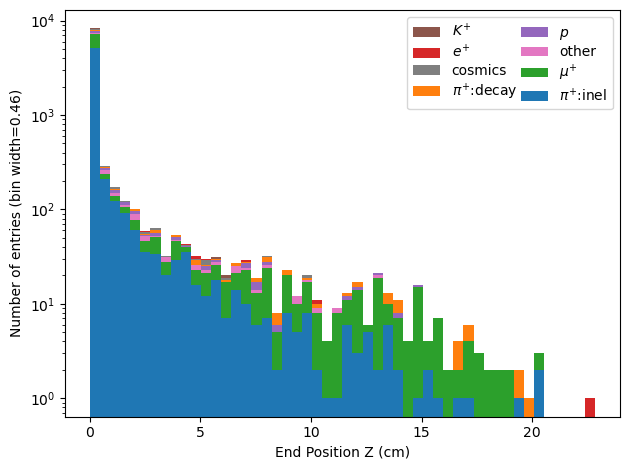

In [33]:
tags = Tags.GenerateBeamCandidateTags(proton_pid_evts)
michel_score = proton_pid_evts.recoParticles.beam_michelScore
Plots.PlotTagged(michel_score, tags, bins=50, y_scale='log', x_label="Beam Michel score")

In [38]:
def purity_efficiency(evts, ini_evts):

    def signal_mask(evts):
        return evts.trueParticlesBT.beam_pdg == -13

    purity = ak.sum(signal_mask(evts)) / len(signal_mask(evts))
    efficiency = ak.sum(signal_mask(evts)) / ak.sum(signal_mask(ini_evts))
    return purity, efficiency

In [39]:
rng = np.arange(0, 25, 0.5)
print(rng)
purity, eff = [], []
for cut in rng:
    michel_score = proton_pid_evts.recoParticles.beam_michelScore
    mask = michel_score < cut
    muon_evts = proton_pid_evts.Filter([mask], [mask], returnCopy=True)
    p, e = purity_efficiency(muon_evts, proton_pid_evts)
    purity.append(p)
    eff.append(e)

[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13.  13.5
 14.  14.5 15.  15.5 16.  16.5 17.  17.5 18.  18.5 19.  19.5 20.  20.5
 21.  21.5 22.  22.5 23.  23.5 24.  24.5]


/tmp/ipykernel_1241275/2496286001.py:6: RuntimeWarning: invalid value encountered in scalar divide
  purity = ak.sum(signal_mask(evts)) / len(signal_mask(evts))


In [40]:
np.array(purity)*np.array(eff)

array([       nan, 0.2180812 , 0.21783206, 0.21721326, 0.21894097,
       0.21973718, 0.22157514, 0.22353092, 0.22523703, 0.22555082,
       0.226433  , 0.22763714, 0.22989071, 0.23046875, 0.23242544,
       0.23307978, 0.23599424, 0.23662366, 0.23866471, 0.23932036,
       0.24070927, 0.2419483 , 0.24316491, 0.24379872, 0.24570268,
       0.24626063, 0.24865682, 0.24952193, 0.25023452, 0.25087288,
       0.2531547 , 0.25382161, 0.25487597, 0.25521005, 0.25567153,
       0.25579881, 0.25634037, 0.25706311, 0.25742476, 0.25739803,
       0.25734459, 0.25747198, 0.25747198, 0.25747198, 0.25747198,
       0.25747198, 0.25744526, 0.25744526, 0.25744526, 0.25744526])

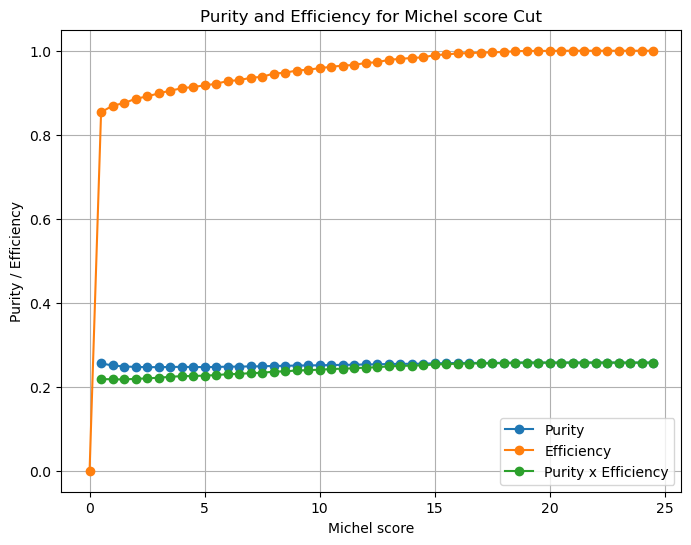

In [41]:
plt.figure(figsize=(8, 6))
plt.plot(rng, purity, marker="o", label="Purity")
plt.plot(rng, eff, marker="o", label="Efficiency")
plt.plot(rng, np.array(purity)*np.array(eff), marker="o", label="Purity x Efficiency")
plt.xlabel("Michel score")
plt.ylabel("Purity / Efficiency")
plt.title("Purity and Efficiency for Michel score Cut")
plt.legend()
plt.grid()
plt.show()

In [13]:
tags = Tags.GenerateTrueBeamParticleTags(track_selected_evts)

pi_inel_mask =tags.mask.values[0]
pi_decay_mask = tags.mask.values[1]
muon_mask = tags.mask.values[2]

In [14]:
ak.sum(pi_inel_mask), ak.sum(pi_decay_mask), ak.sum(muon_mask)

(8214, 784, 1751)

In [15]:
np.unique(track_selected_evts.trueParticles.true_beam_endProcess[muon_mask], return_counts=True)

(array(['Decay'], dtype='<U5'), array([1751]))

In [16]:
np.unique(ak.num(track_selected_evts.trueParticles.endPos[pi_inel_mask]), return_counts=True)

(array([ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
        21, 22, 23, 24, 25, 26, 27, 28, 29, 30]),
 array([  3, 157, 432, 513, 572, 620, 639, 582, 571, 552, 514, 492, 451,
        436, 381, 344, 272, 205, 174, 134,  79,  43,  26,  15,   4,   2,
          1]))

In [17]:
np.unique(ak.num(track_selected_evts.trueParticles.endPos[pi_decay_mask]), return_counts=True)

(array([3, 4, 5, 6, 7, 8]), array([687,  67,  19,   8,   2,   1]))

In [18]:
track_selected_evts.trueParticles.endPos.z

<Array [[-8.58, 12.6, -8.58, ... 74, 74]] type='10749 * var * float64'>

(array([ 0.,  0.,  0.,  1.,  0.,  1.,  0.,  1.,  2.,  6.,  5.,  8.,  9.,
        14., 21., 24., 23., 34., 27., 25., 28., 40., 36., 41., 36., 45.,
        35., 38., 29., 40., 33., 25., 29., 32., 23., 15., 14.,  8.,  9.,
         5.,  4.,  6.,  3.,  4.,  1.,  1.,  0.,  0.,  0.]),
 array([ 800.        ,  808.16326531,  816.32653061,  824.48979592,
         832.65306122,  840.81632653,  848.97959184,  857.14285714,
         865.30612245,  873.46938776,  881.63265306,  889.79591837,
         897.95918367,  906.12244898,  914.28571429,  922.44897959,
         930.6122449 ,  938.7755102 ,  946.93877551,  955.10204082,
         963.26530612,  971.42857143,  979.59183673,  987.75510204,
         995.91836735, 1004.08163265, 1012.24489796, 1020.40816327,
        1028.57142857, 1036.73469388, 1044.89795918, 1053.06122449,
        1061.2244898 , 1069.3877551 , 1077.55102041, 1085.71428571,
        1093.87755102, 1102.04081633, 1110.20408163, 1118.36734694,
        1126.53061224, 1134.69387755, 114

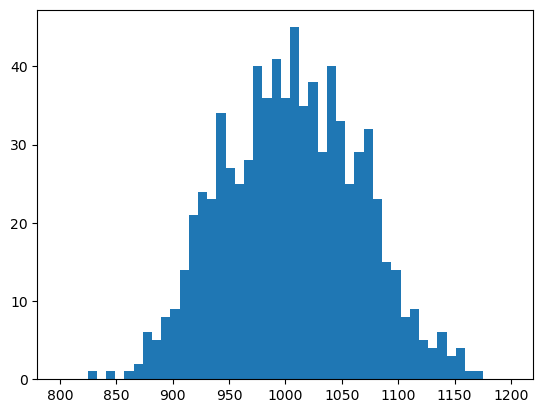

In [19]:
tags = Tags.GenerateTrueBeamParticleTags(track_selected_evts)
reco_beam_inst_P = track_selected_evts.recoParticles.beam_inst_P
bins = np.linspace(800, 1200, 50)
plt.hist(reco_beam_inst_P[pi_decay_mask], bins=bins, label="Pi Decay")
#Plots.PlotTagged(reco_beam_inst_P[pi_decay_mask], tags, bins=bins, y_scale='linear', x_label="Reconstructed Momentum [MeV/c]")

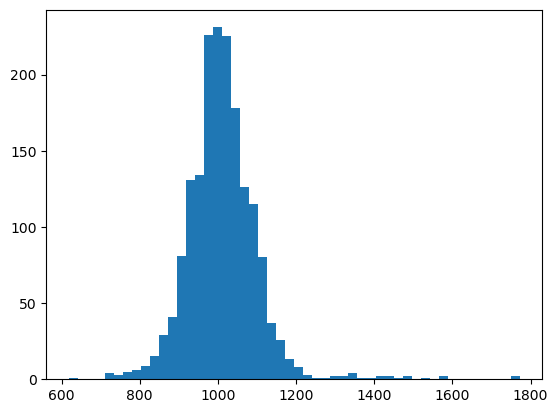

In [20]:
reco_beam_inst_P = track_selected_evts.recoParticles.beam_inst_P
bins = np.linspace(800, 1200, 50)
plt.hist(reco_beam_inst_P[muon_mask], bins=50, label="Pi Decay")
plt.show()

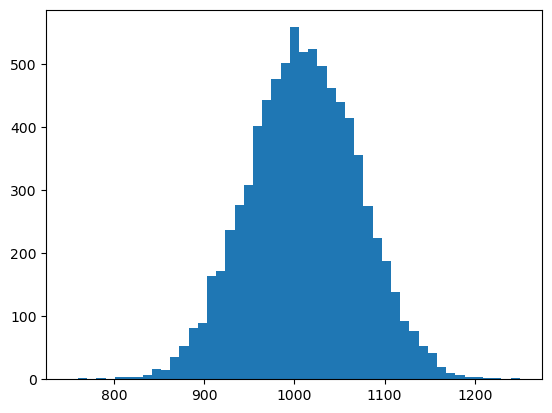

In [21]:
reco_beam_inst_P = track_selected_evts.recoParticles.beam_inst_P
bins = np.linspace(750, 1250, 50)
plt.hist(reco_beam_inst_P[pi_inel_mask], bins=bins, label="Pi inelastic")

plt.show()

(array([31., 30., 19., 29., 30., 31., 24., 35., 25., 30., 28., 24., 18.,
        22., 21., 37., 24., 24., 28., 31., 23., 30.,  9., 19., 12., 10.,
         8., 13.,  5.,  8., 10.,  5.,  6.,  4.,  2.,  5.,  1.,  2.,  2.,
         3.,  5.,  4.,  6., 14., 11.,  7.,  7.,  7.,  4.,  1.]),
 array([-273.94907411, -260.37067467, -246.79227522, -233.21387578,
        -219.63547633, -206.05707689, -192.47867744, -178.90027799,
        -165.32187855, -151.7434791 , -138.16507966, -124.58668021,
        -111.00828077,  -97.42988132,  -83.85148188,  -70.27308243,
         -56.69468299,  -43.11628354,  -29.5378841 ,  -15.95948465,
          -2.38108521,   11.19731424,   24.77571369,   38.35411313,
          51.93251258,   65.51091202,   79.08931147,   92.66771091,
         106.24611036,  119.8245098 ,  133.40290925,  146.98130869,
         160.55970814,  174.13810758,  187.71650703,  201.29490648,
         214.87330592,  228.45170537,  242.03010481,  255.60850426,
         269.1869037 ,  282.76530315

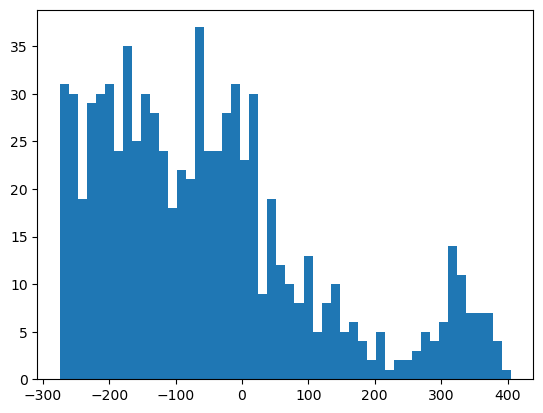

In [22]:
plt.hist(track_selected_evts.trueParticles.endPos.z[pi_decay_mask][:, 0], bins=50)

In [23]:
ak.sum(track_selected_evts.trueParticles.endPos.z[pi_decay_mask][:, 0] <=0), ak.sum(track_selected_evts.trueParticles.endPos.z[muon_mask][:, 0] < 270)

(544, 554)

(array([  5.,   8.,   8.,   6.,  10.,   9.,  17.,  22.,  16.,  19.,  21.,
         24.,  32.,  50.,  43.,  57.,  41.,  35.,  30.,  29.,  29.,  23.,
         22.,  37.,  31.,  41.,  56.,  77., 123., 149., 154., 151., 111.,
         99.,  80.,  34.,  33.,   5.,   4.,   1.,   0.,   1.,   4.,   1.,
          0.,   1.,   1.,   0.,   0.,   1.]),
 array([  8.04495508,  19.45730178,  30.86964847,  42.28199517,
         53.69434187,  65.10668857,  76.51903527,  87.93138197,
         99.34372866, 110.75607536, 122.16842206, 133.58076876,
        144.99311546, 156.40546216, 167.81780886, 179.23015555,
        190.64250225, 202.05484895, 213.46719565, 224.87954235,
        236.29188905, 247.70423575, 259.11658244, 270.52892914,
        281.94127584, 293.35362254, 304.76596924, 316.17831594,
        327.59066263, 339.00300933, 350.41535603, 361.82770273,
        373.24004943, 384.65239613, 396.06474283, 407.47708952,
        418.88943622, 430.30178292, 441.71412962, 453.12647632,
        464.538823

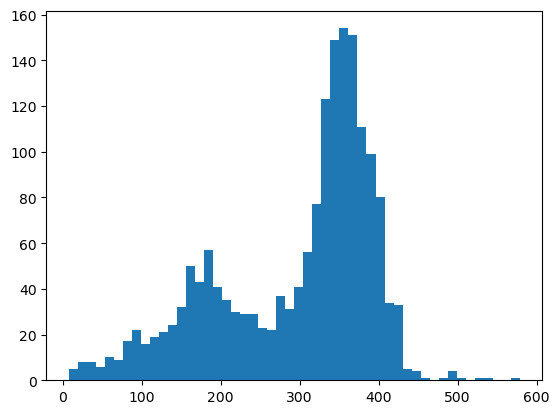

In [24]:
plt.hist(track_selected_evts.trueParticles.endPos.z[muon_mask][:, 0], bins=50)

In [25]:
filename = "/storage/2/gj23442/PDSPProd4a_MC_1GeV_reco1_sce_datadriven_v1_ntuple_v09_41_00_03.root"
events_pdsp = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

## Beam Instrumentation Selection

true_beam_mask = beam_selection.BeamTriggerSelection(events_pdsp, return_property=True)
mask = true_beam_mask[0]
bi_evts = events_pdsp.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
track_selected_evts_pdsp = track_evts.Filter([mask], [mask], returnCopy=True)

In [26]:
tags = Tags.GenerateTrueBeamParticleTags(track_selected_evts_pdsp)

pi_inel_mask =tags.mask.values[0]
pi_decay_mask = tags.mask.values[1]
muon_mask = tags.mask.values[2]

In [27]:
ak.sum(track_selected_evts_pdsp.trueParticles.endPos.z[pi_decay_mask][:, 0] <=0), ak.sum(track_selected_evts_pdsp.trueParticles.endPos.z[muon_mask][:, 0] < 230)

(2691, 2952)

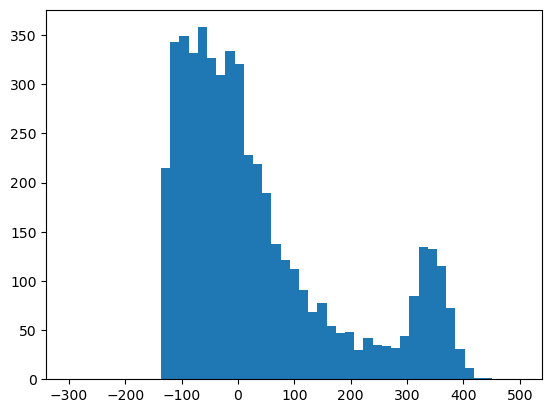

In [28]:
plt.hist(track_selected_evts_pdsp.trueParticles.endPos.z[pi_decay_mask][:, 0], bins=np.linspace(-300, 500, 50))
plt.show()

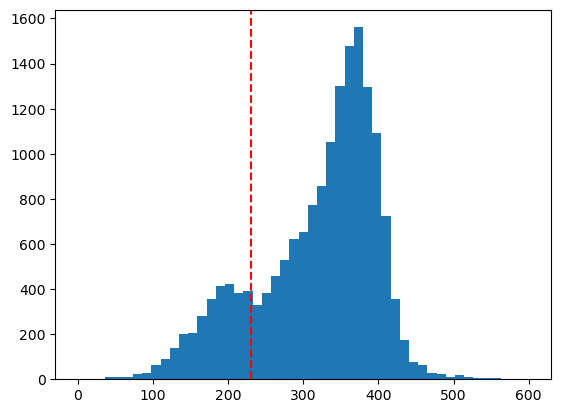

In [29]:
plt.hist(track_selected_evts_pdsp.trueParticles.endPos.z[muon_mask][:, 0], bins=np.linspace(0, 600, 50))
plt.axvline(x=230, color='r', linestyle='--', label='230 cm')
plt.show()

In [30]:
tags = Tags.GenerateTrueBeamParticleTags(track_selected_evts)
reco_beam_inst_P = track_selected_evts.recoParticles.beam_inst_P
reco_beam_inst_P[tags.mask.values[1]]

<Array [1.08e+03, 929, ... 1.08e+03, 1.1e+03] type='784 * float64'>

(array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  1.,  8.,
         9.,  8., 17., 23., 33., 30., 40., 35., 42., 40., 51., 53., 48.,
        42., 45., 45., 41., 37., 35., 27., 18., 15., 11.,  5.,  6.,  6.,
         5.,  1.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  0.]),
 array([ 750.        ,  760.20408163,  770.40816327,  780.6122449 ,
         790.81632653,  801.02040816,  811.2244898 ,  821.42857143,
         831.63265306,  841.83673469,  852.04081633,  862.24489796,
         872.44897959,  882.65306122,  892.85714286,  903.06122449,
         913.26530612,  923.46938776,  933.67346939,  943.87755102,
         954.08163265,  964.28571429,  974.48979592,  984.69387755,
         994.89795918, 1005.10204082, 1015.30612245, 1025.51020408,
        1035.71428571, 1045.91836735, 1056.12244898, 1066.32653061,
        1076.53061224, 1086.73469388, 1096.93877551, 1107.14285714,
        1117.34693878, 1127.55102041, 1137.75510204, 1147.95918367,
        1158.16326531, 1168.36734694, 117

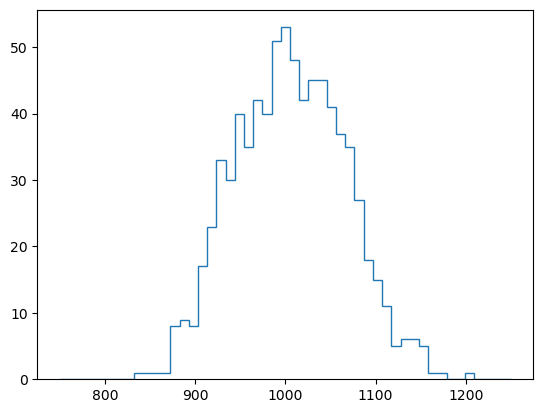

In [31]:
bins = np.linspace(750, 1250, 50)
plt.hist(reco_beam_inst_P[tags.mask.values[1]], bins=bins, histtype='step')

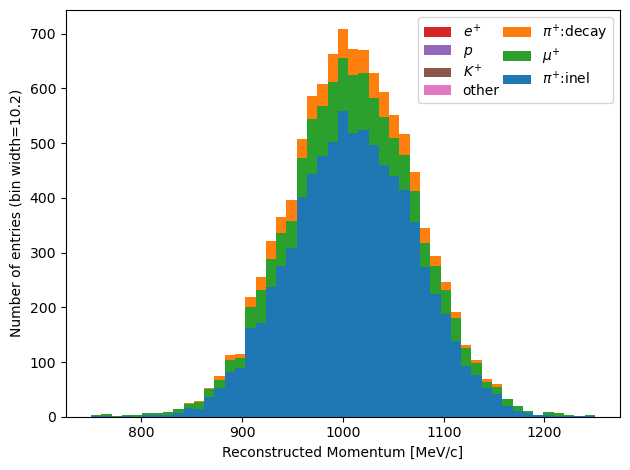

In [32]:
tags = Tags.GenerateTrueBeamParticleTags(track_selected_evts)
reco_beam_inst_P = track_selected_evts.recoParticles.beam_inst_P
bins = np.linspace(750, 1250, 50)
# plt.hist(reco_beam_inst_P, bins=bins, histtype='step')
# plt.xlabel("Reconstructed Momentum [MeV/c]")
# plt.show()
Plots.PlotTagged(reco_beam_inst_P, tags, bins=bins, y_scale='linear', x_label="Reconstructed Momentum [MeV/c]")

In [33]:
def tpc_entrance_mask(evts):
    traj_z = evts.trueParticles.beam_traj_pos.z
    traj_z = traj_z[traj_z >= 0]
    mask = evts.trueParticles.beam_traj_pos.z == ak.firsts(traj_z)
    return mask

def ke_to_p(evts):
    ff_mask = beam_selection.tpc_entrance_mask(evts)
    true_KE_ff = ak.fill_none(ak.firsts(evts.trueParticles.beam_traj_KE[ff_mask]), 0)
    pdg = evts.trueParticles.pdg[:, 0]
    mass = ak.where(pdg == 211, 139.57, ak.where(pdg == -13, 105.66, 0))
    return ((true_KE_ff + mass)**2 - mass**2)**0.5

In [34]:
traj_z = track_selected_evts.trueParticles.beam_traj_pos.z
start_z_mask = track_selected_evts.trueParticles.beam_traj_pos.z == ak.firsts(traj_z)

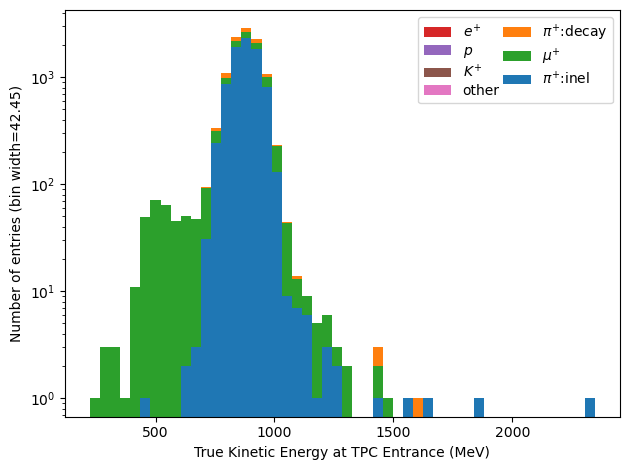

In [35]:
start_z_mask = track_selected_evts.trueParticles.beam_traj_pos.z == ak.firsts(traj_z)
tags = Tags.GenerateTrueBeamParticleTags(track_selected_evts)
true_KE_ff = ak.fill_none(ak.firsts(track_selected_evts.trueParticles.beam_traj_KE[start_z_mask]), 0)
#bins = np.linspace(0, 1500, 50)
Plots.PlotTagged(true_KE_ff, tags, bins=50, y_scale='log', x_label="True Kinetic Energy at TPC Entrance (MeV)")

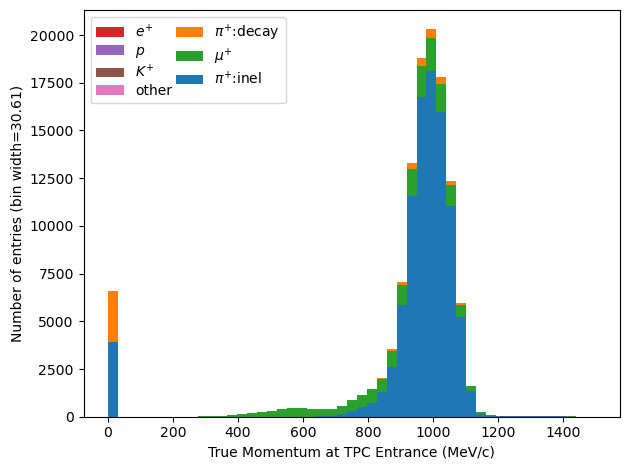

In [36]:
ff_mask = beam_selection.tpc_entrance_mask(track_selected_evts_pdsp)
tags = Tags.GenerateTrueBeamParticleTags(track_selected_evts_pdsp)
true_KE_ff = ak.fill_none(ak.firsts(track_selected_evts_pdsp.trueParticles.beam_traj_KE[ff_mask]), 0)
true_P_ff = ke_to_p(track_selected_evts_pdsp)
bins = np.linspace(0, 1500, 50)
Plots.PlotTagged(true_P_ff, tags, bins=bins, y_scale='linear', x_label="True Momentum at TPC Entrance (MeV/c)")

In [37]:
ff_mask = beam_selection.tpc_entrance_mask(track_selected_evts)
tags = Tags.GenerateTrueBeamParticleTags(track_selected_evts)
true_KE_ff = ak.fill_none(ak.firsts(track_selected_evts.trueParticles.beam_traj_KE[ff_mask]), 0)

In [38]:
ak.sum(true_KE_ff[tags.mask.values[2]]<700)

625

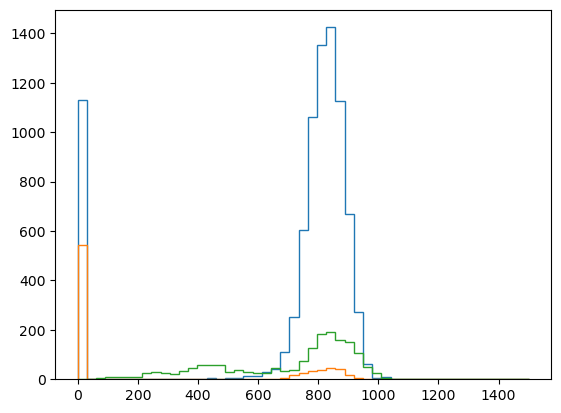

In [39]:
ff_mask = beam_selection.tpc_entrance_mask(track_selected_evts)
tags = Tags.GenerateTrueBeamParticleTags(track_selected_evts)
true_KE_ff = ak.fill_none(ak.firsts(track_selected_evts.trueParticles.beam_traj_KE[ff_mask]), 0)
#true_P_ff = ke_to_p(track_selected_evts)
bins = np.linspace(0, 1500, 50)
plt.hist(true_KE_ff[tags.mask.values[0]], bins=bins, histtype='step')
plt.hist(true_KE_ff[tags.mask.values[1]], bins=bins, histtype='step')
plt.hist(true_KE_ff[tags.mask.values[2]], bins=bins, histtype='step')
plt.show()

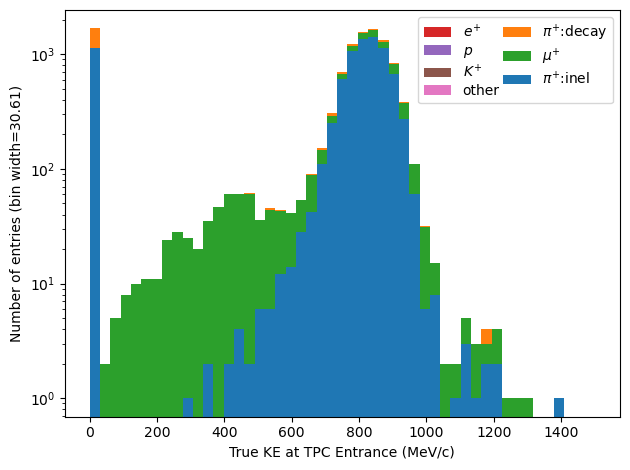

In [40]:
ff_mask = beam_selection.tpc_entrance_mask(track_selected_evts)
tags = Tags.GenerateTrueBeamParticleTags(track_selected_evts)
true_KE_ff = ak.fill_none(ak.firsts(track_selected_evts.trueParticles.beam_traj_KE[ff_mask]), 0)
#true_P_ff = ke_to_p(track_selected_evts)
bins = np.linspace(0, 1500, 50)
Plots.PlotTagged(true_KE_ff, tags, bins=bins, y_scale='log', x_label="True KE at TPC Entrance (MeV/c)")

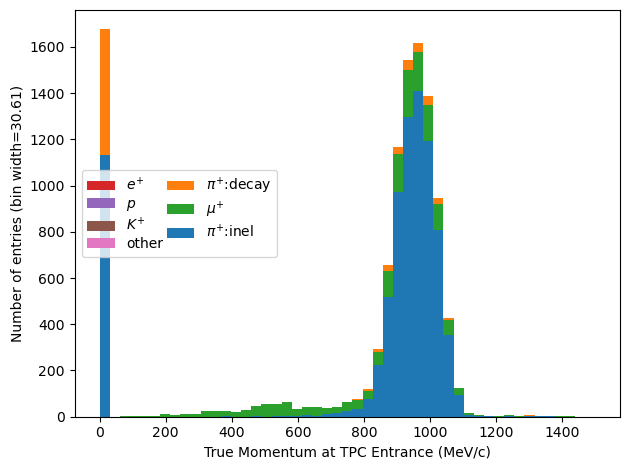

In [41]:
ff_mask = beam_selection.tpc_entrance_mask(track_selected_evts)
tags = Tags.GenerateTrueBeamParticleTags(track_selected_evts)
true_KE_ff = ak.fill_none(ak.firsts(track_selected_evts.trueParticles.beam_traj_KE[ff_mask]), 0)
true_P_ff = ke_to_p(track_selected_evts)
bins = np.linspace(0, 1500, 50)
Plots.PlotTagged(true_P_ff, tags, bins=bins, y_scale='linear', x_label="True Momentum at TPC Entrance (MeV/c)")

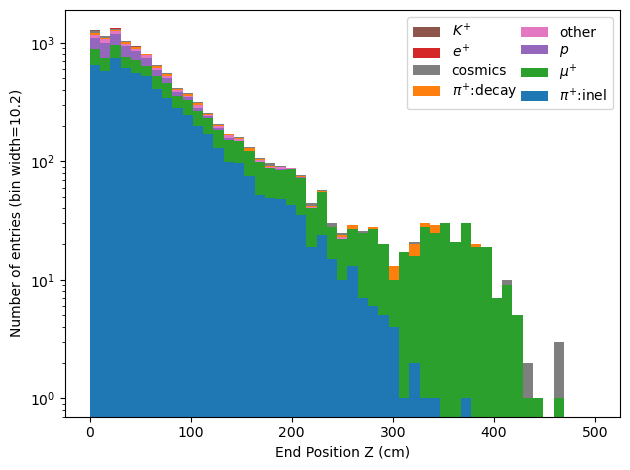

In [42]:
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
end_pos = track_selected_evts.recoParticles.beam_endPos_SCE.z
bins = np.linspace(0, 500, 50)
Plots.PlotTagged(end_pos, tags, bins=bins, y_scale='log', x_label="End Position Z (cm)")

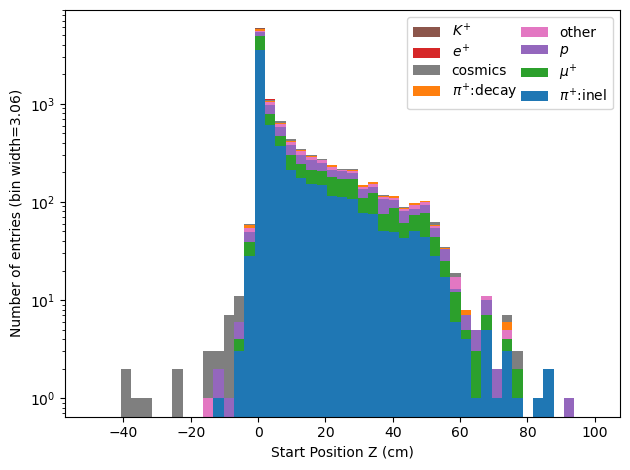

In [43]:
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
start_pos = track_selected_evts.recoParticles.beam_startPos_SCE.z
bins = np.linspace(-50, 100, 50)
Plots.PlotTagged(start_pos, tags, bins=bins, y_scale='log', x_label="Start Position Z (cm)")

In [44]:
ak.sum((track_selected_evts.recoParticles.reco_beam_len < 5) | 
(track_selected_evts.recoParticles.beam_endPos_SCE.z < 25) | 
(track_selected_evts.recoParticles.beam_endPos_SCE.y < 200) | 
(track_selected_evts.recoParticles.beam_endPos_SCE.x < -200) |
(track_selected_evts.recoParticles.beam_endPos_SCE.y > 500) |
(track_selected_evts.recoParticles.beam_endPos_SCE.x > 0))

3100

In [45]:
michel_score = track_selected_evts.recoParticles.beam_michelScore
ak.sum(michel_score == -1) 

9488

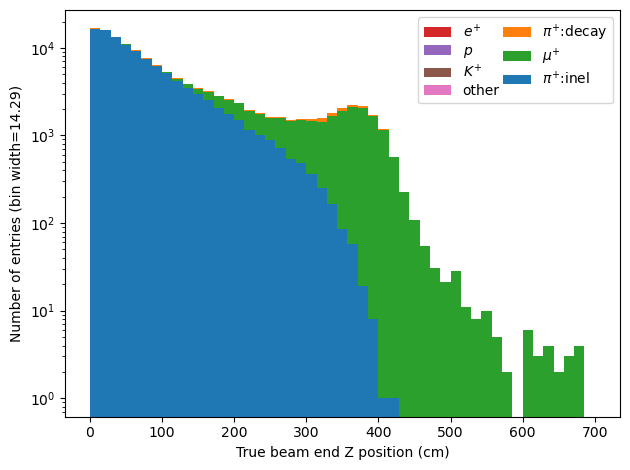

In [46]:
tags = Tags.GenerateTrueBeamParticleTags(track_evts)
Plots.PlotTagged(ak.firsts(track_evts.trueParticles.endPos.z), tags, bins=np.linspace(0, 700, 50), y_scale='log', x_label="True beam end Z position (cm)")

1131
636


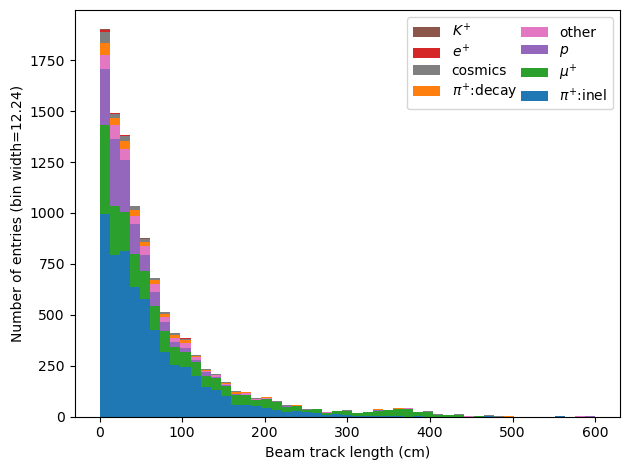

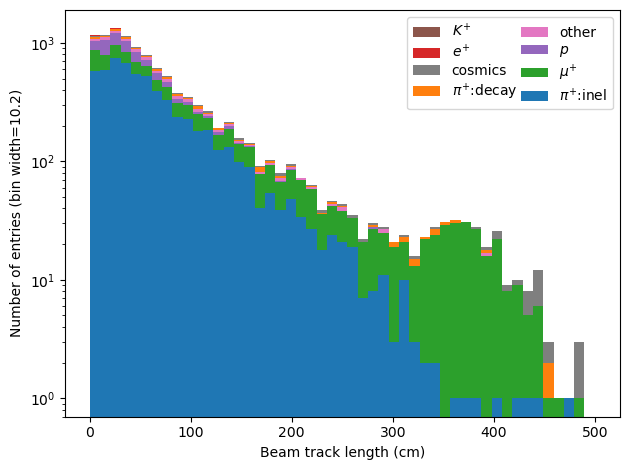

In [47]:
beam_trk_len = track_selected_evts.recoParticles.beam_track_length
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
print(np.sum(beam_trk_len < 5))
bins_1=np.linspace(0, 600, 50)
Plots.PlotTagged(beam_trk_len, tags, bins=bins_1, y_scale='linear', x_label="Beam track length (cm)")
#plt.ylim(0, 2000)

trk_len = track_selected_evts.recoParticles.reco_beam_len
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
print(np.sum(trk_len < 5))
bins_2 = np.linspace(0, 500, 50)
Plots.PlotTagged(trk_len, tags, bins=bins_2, y_scale='log', x_label="Beam track length (cm)")

In [48]:
purity_eff_dict = {}
n_sig_true = ak.sum(beam_selection.true_signal_mask(events))
n_sig_bt   = ak.sum(beam_selection.signal_mask(events))

purity_eff_dict = {}
for evts, label in zip([events, bi_evts, bv_evts, track_evts, track_selected_evts],
                        ["All events", "Beam trigger", "Beam valid", "Beam track", "Beam quality"]):
    purity_eff_dict[label] = {
        "Purity":                  float(ak.sum(beam_selection.signal_mask(evts))      / len(beam_selection.signal_mask(evts))),
        "True efficiency":         float(ak.sum(beam_selection.true_signal_mask(evts)) / n_sig_true),
        "Backtracked efficiency":  float(ak.sum(beam_selection.signal_mask(evts))      / n_sig_bt),
    }

pur_eff_df = pd.DataFrame(purity_eff_dict)
pur_eff_df.loc["Rel. true efficiency"] = pur_eff_df.loc["True efficiency"] / pur_eff_df.loc["True efficiency"].shift(1)
pur_eff_df.loc["Rel. BT efficiency"]   = pur_eff_df.loc["Backtracked efficiency"] / pur_eff_df.loc["Backtracked efficiency"].shift(1)

In [49]:
pur_eff_df.style.format("{:.1%}")

,All events,Beam trigger,Beam valid,Beam track,Beam quality
Purity,7.6%,54.6%,62.0%,63.5%,59.2%
True efficiency,100.0%,586.2%,513.7%,495.4%,36.6%
Backtracked efficiency,100.0%,677.8%,677.8%,672.4%,46.4%
Rel. true efficiency,nan%,586.2%,87.6%,96.4%,7.4%
Rel. BT efficiency,nan%,677.8%,100.0%,99.2%,6.9%


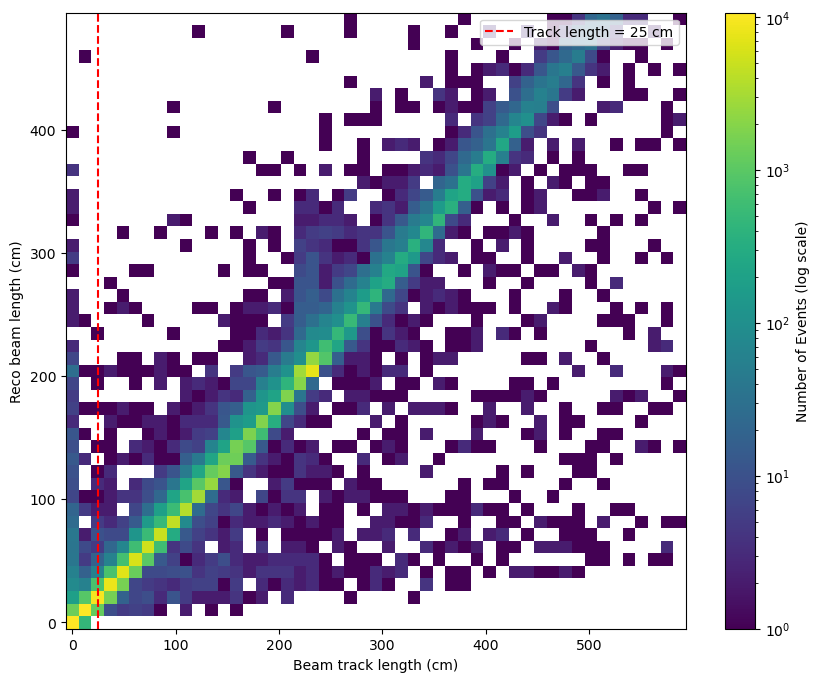

In [50]:
beam_trk_len = track_evts.recoParticles.beam_track_length
trk_len = track_evts.recoParticles.reco_beam_len

hist, xedges, yedges = np.histogram2d(beam_trk_len, trk_len, bins=(bins_1, bins_2))
X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
plt.figure(figsize=(10, 8))
plt.pcolormesh(X, Y, hist.T, norm=mcolors.LogNorm())
plt.xlabel("Beam track length (cm)")
plt.ylabel("Reco beam length (cm)")   
plt.axvline(25, color='red', linestyle='--', label='Track length = 25 cm')
plt.colorbar(label="Number of Events (log scale)")
plt.legend()
plt.show()

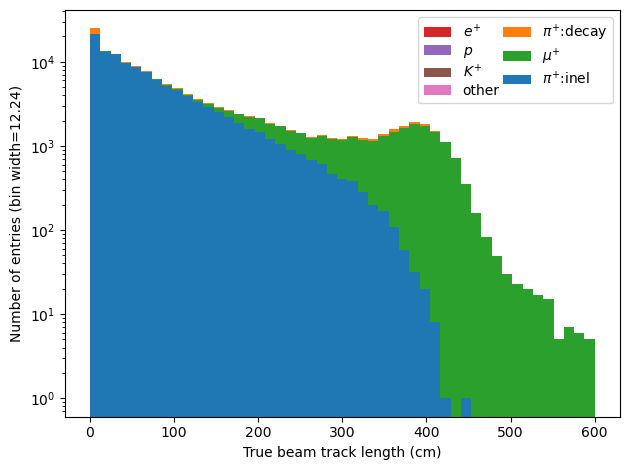

In [51]:
tags = Tags.GenerateTrueBeamParticleTags(track_evts)
true_beam_len = track_evts.trueParticles.beam_track_length
Plots.PlotTagged(true_beam_len, tags, bins=np.linspace(0, 600, 50), y_scale='log', x_label="True beam track length (cm)")

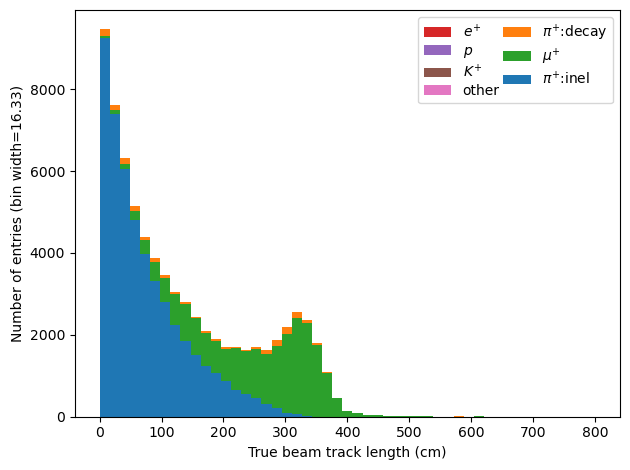

In [52]:
tags = Tags.GenerateTrueBeamParticleTags(track_evts)
beam_len = track_evts.trueParticles.beam_len
bins = np.linspace(0, 800, 50)
Plots.PlotTagged(beam_len - 200, tags, bins=bins, y_scale='linear', x_label="True beam track length (cm)")

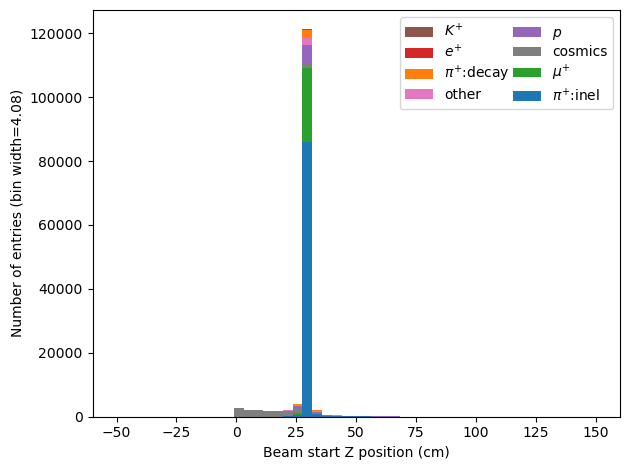

In [53]:
start_pos = track_evts.recoParticles.beam_startPos_SCE
tags = Tags.GenerateBeamCandidateTags(track_evts)
Plots.PlotTagged(start_pos.z, tags, bins=np.linspace(-50, 150, 50), y_scale='linear', x_label="Beam start Z position (cm)")

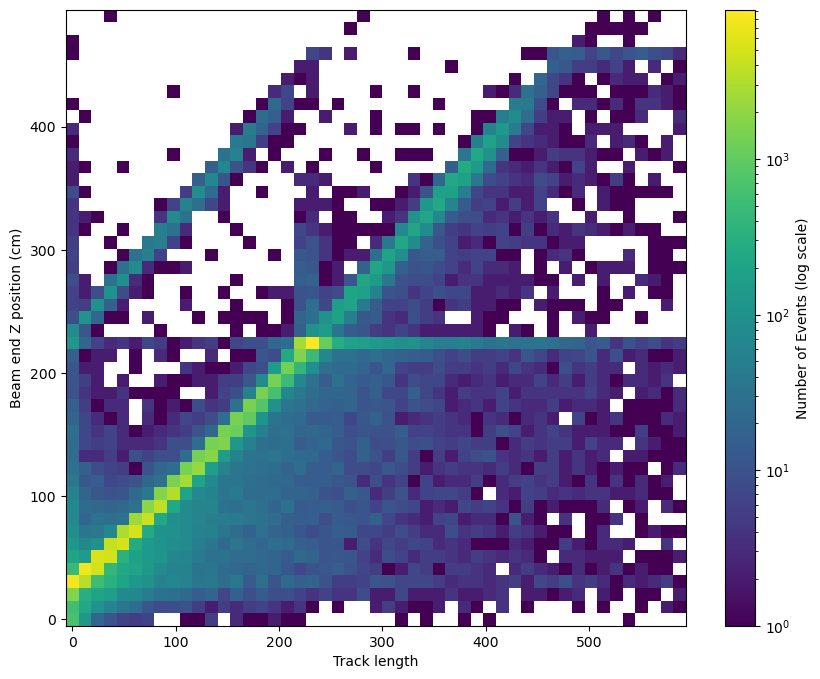

In [54]:
track_len = track_evts.recoParticles.beam_track_length
end_pos = track_evts.recoParticles.beam_endPos_SCE.z
hist, xedges, yedges = np.histogram2d(track_len, end_pos, bins=(np.linspace(0, 600, 50), np.linspace(0, 500, 50)))
X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
plt.figure(figsize=(10, 8))
plt.pcolormesh(X, Y, hist.T, norm=mcolors.LogNorm())
plt.xlabel("Track length")
plt.ylabel("Beam end Z position (cm)")
#plt.axvline(25, color='red', linestyle='--', label='25 cm Track Length')
plt.colorbar(label="Number of Events (log scale)")
plt.show()

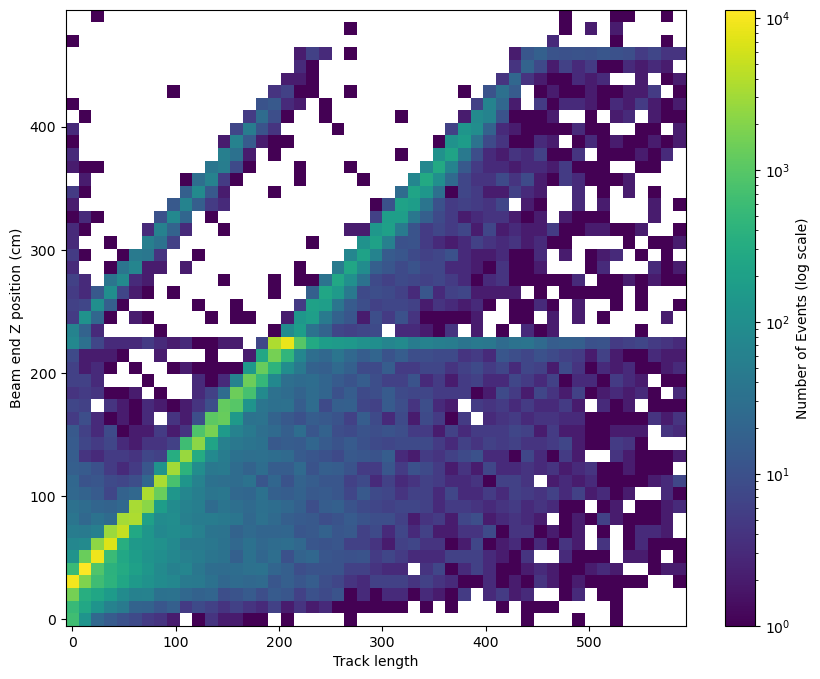

In [55]:
track_len = track_evts.recoParticles.reco_beam_len
end_pos = track_evts.recoParticles.beam_endPos_SCE.z
hist, xedges, yedges = np.histogram2d(track_len, end_pos, bins=(np.linspace(0, 600, 50), np.linspace(0, 500, 50)))
X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
plt.figure(figsize=(10, 8))
plt.pcolormesh(X, Y, hist.T, norm=mcolors.LogNorm())
plt.xlabel("Track length")
plt.ylabel("Beam end Z position (cm)")
#plt.axvline(25, color='red', linestyle='--', label='25 cm Track Length')
plt.colorbar(label="Number of Events (log scale)")
plt.show()

In [56]:
short_track_mask = track_evts.recoParticles.beam_track_length < 25
short_track_evts = track_evts.Filter([short_track_mask], [short_track_mask], returnCopy=True)
rest_track_evts = track_evts.Filter([~short_track_mask], [~short_track_mask], returnCopy=True)
print(ak.sum(short_track_mask))

25246


693


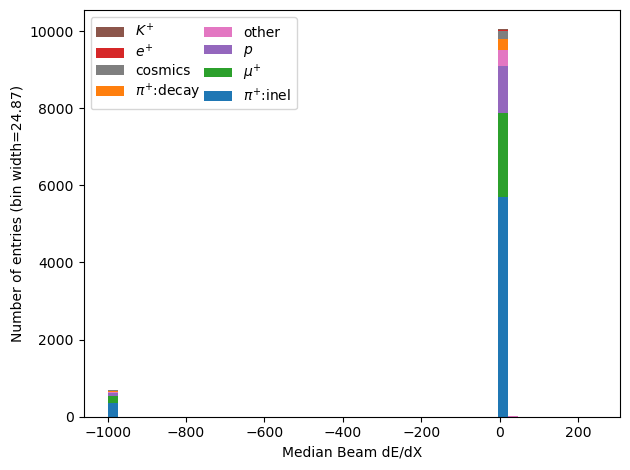

In [57]:
from python.analysis.PFOSelection import Median

median = Median(track_selected_evts.recoParticles.beam_dEdX)
print(ak.sum(median == -999))

median = Median(track_selected_evts.recoParticles.beam_dEdX)
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
bins=np.linspace(0, 10, 50)
Plots.PlotTagged(median, tags, bins=50, y_scale="linear", x_label="Median Beam dE/dX")

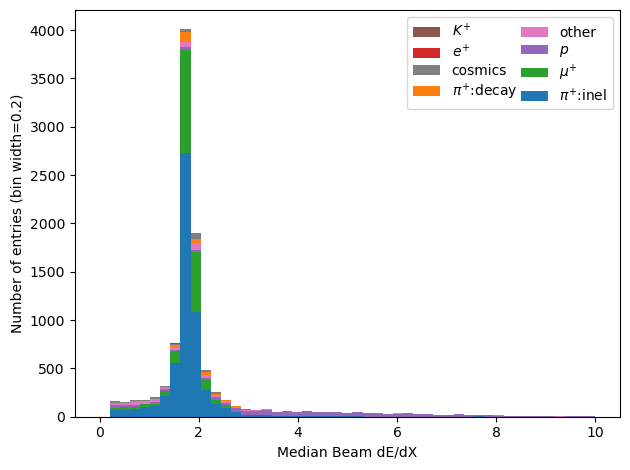

In [58]:
median = Median(track_selected_evts.recoParticles.beam_dEdX)
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(median, tags, bins=np.linspace(0, 10, 50), y_scale="linear", x_label="Median Beam dE/dX")

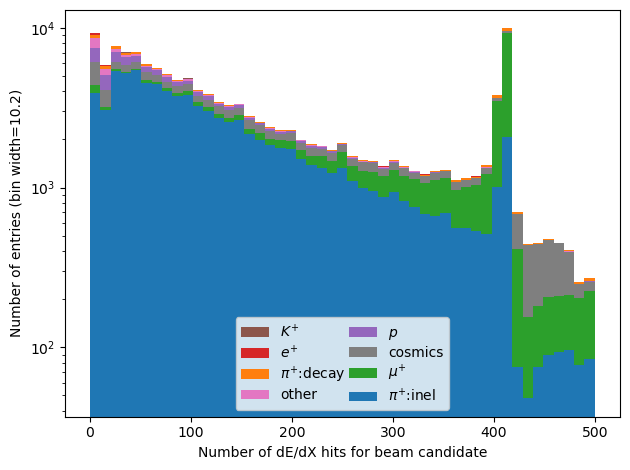

In [59]:
beam_dEdX = track_evts.recoParticles.beam_dEdX
n_hits = ak.num(beam_dEdX)
tags = Tags.GenerateBeamCandidateTags(track_evts)
Plots.PlotTagged(n_hits, tags, bins=np.linspace(0, 500, 50), y_scale="log", x_label="Number of dE/dX hits for beam candidate")

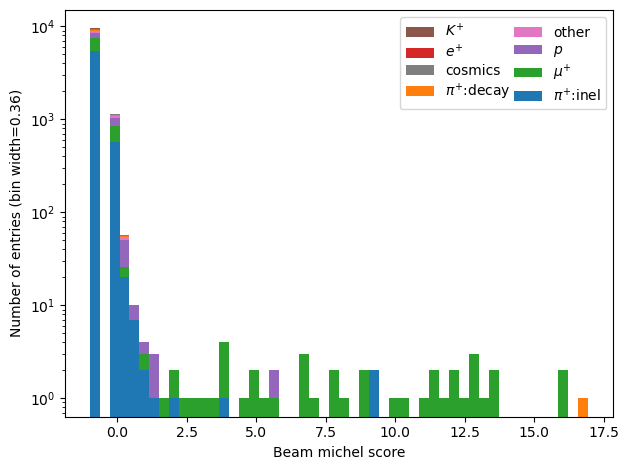

In [60]:
tags = Tags.GenerateBeamCandidateTags(track_selected_evts)
Plots.PlotTagged(track_selected_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")

In [61]:
def signal_mask(evts):
    mask = (evts.trueParticlesBT.beam_pdg == 211) 
    return mask

ini_evts = signal_mask(track_evts)

def purity_efficiency(evts, filter_func):
    purity = ak.sum(filter_func(evts)) / len(filter_func(evts))
    efficiency = ak.sum(filter_func(evts)) / ak.sum(ini_evts)
    return purity, efficiency

In [62]:
rng = np.arange(0, 70, 10)
purity, eff = [], []
for cut in rng:
    mask = track_evts.recoParticles.beam_endPos_SCE.z > cut
    fiducial_evts = track_evts.Filter([mask], [mask], returnCopy=True)
    p, e = purity_efficiency(fiducial_evts, signal_mask)
    purity.append(p)
    eff.append(e)

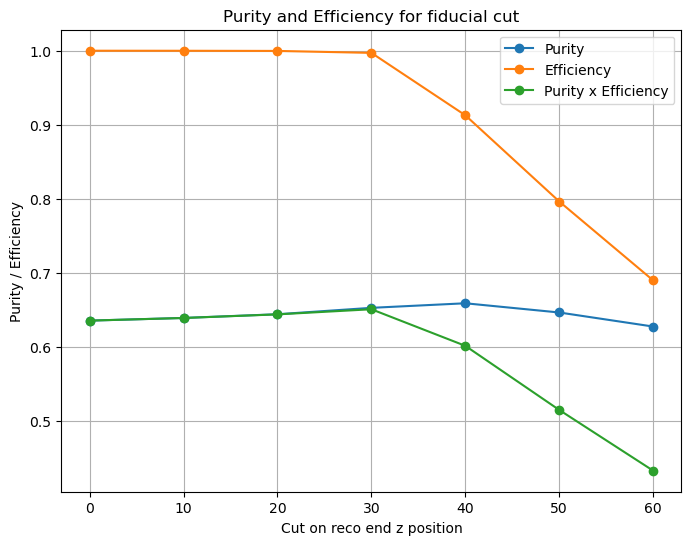

In [63]:
plt.figure(figsize=(8, 6))
plt.plot(rng, purity, marker="o", label="Purity")
plt.plot(rng, eff, marker="o", label="Efficiency")
plt.plot(rng, np.array(purity)*np.array(eff), marker="o", label="Purity x Efficiency")
plt.xlabel("Cut on reco end z position")
plt.ylabel("Purity / Efficiency")
plt.title("Purity and Efficiency for fiducial cut")
plt.legend()
plt.grid()
plt.show()

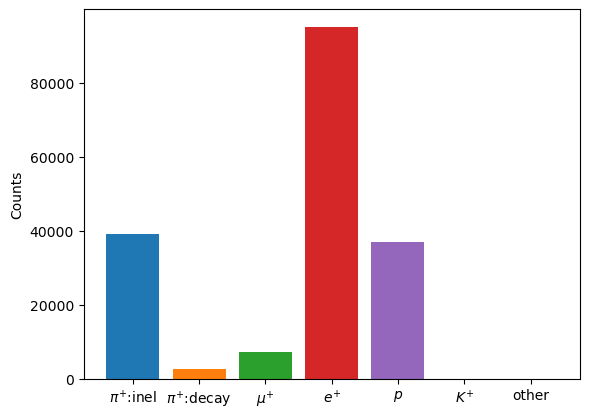

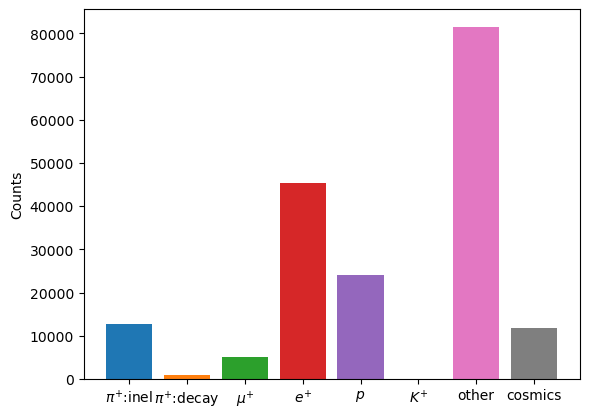

In [64]:
tags = Tags.GenerateTrueBeamParticleTags(events)
counts = ak.sum(tags.mask.values, axis=-1)
#counts = counts / np.sum(counts)  # Normalise counts to get percentages
plt.bar(tags.name.values, counts, color= tags.colour.values)
plt.ylabel("Counts")
#plt.yscale("log")
plt.show()


tags = Tags.GenerateBeamCandidateTags(events)
counts = ak.sum(tags.mask.values, axis=-1)
#counts = counts / np.sum(counts)  # Normalise counts to get percentages
plt.bar(tags.name.values, counts, color= tags.colour.values)
plt.ylabel("Counts")
#plt.yscale("log")
plt.show()

In [65]:
purity = ak.sum(beam_selection.signal_mask(events)) / len(beam_selection.signal_mask(events))
print(f"Purity of the sample: {purity:.2%}")

true_purity = ak.sum(beam_selection.true_signal_mask(events)) / len(beam_selection.true_signal_mask(events))
print(f"Purity of the sample from truth info: {true_purity:.2%}")

Purity of the sample: 7.55%
Purity of the sample from truth info: 13.56%


In [66]:
# Diagnostic checks to understand how to match true to backtracked particles

print(ak.sum(ak.firsts(events.trueParticles.number)==1))
print(ak.sum(ak.firsts(events.trueParticlesBT.number)==1))
print(ak.sum(ak.firsts(events.trueParticlesBT.number)==ak.firsts(events.trueParticles.number)))
print(ak.sum(events.trueParticles.true_beam_endProcess == events.trueParticlesBT.beam_endProcess))
print(ak.sum(events.trueParticles.true_beam_endProcess == "pi+Inelastic"))
print(ak.sum(events.trueParticlesBT.beam_endProcess == "pi+Inelastic"))

106513
24583
41616
81704
39171
12822


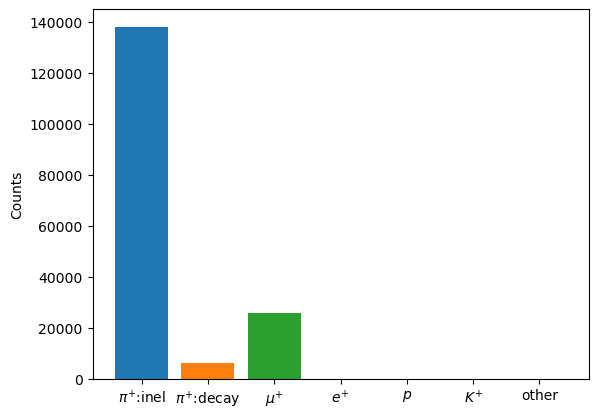

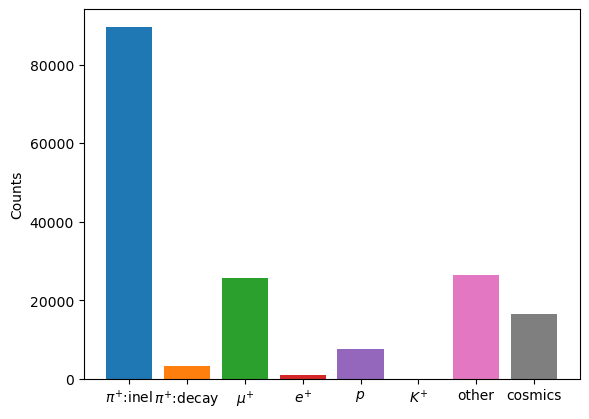

In [67]:
## True Beam Particle distribution (BI)

tags = Tags.GenerateTrueBeamParticleTags(bi_evts)
counts = ak.sum(tags.mask.values, axis=-1)
#counts = counts / np.sum(counts)  # Normalise counts to get percentages
plt.bar(tags.name.values, counts, color= tags.colour.values)
plt.ylabel("Counts")
#plt.yscale("log")
plt.show()

## Reco beam Candidate distribution (BI)

tags = Tags.GenerateBeamCandidateTags(bi_evts)
counts = ak.sum(tags.mask.values, axis=-1)
#counts = counts / np.sum(counts)  # Normalise counts to get percentages
plt.bar(tags.name.values, counts, color= tags.colour.values)
plt.ylabel("Counts")
#plt.yscale("log")
plt.show()

In [68]:
purity = ak.sum(beam_selection.signal_mask(bi_evts)) / len(beam_selection.signal_mask(bi_evts))
print(f"Purity after BI selection: {purity:.2%}")

eff_bt = ak.sum(beam_selection.signal_mask(bi_evts)) / ak.sum(beam_selection.signal_mask(events))
eff_true = ak.sum(beam_selection.true_signal_mask(bi_evts)) / ak.sum(beam_selection.true_signal_mask(events))
print(f"Efficiency of the BI selection from backtracking: {eff_bt:.2%}")
print(f"Efficiency of the BI selection from truth info: {eff_true:.2%}")

Purity after BI selection: 54.56%
Efficiency of the BI selection from backtracking: 677.80%
Efficiency of the BI selection from truth info: 586.18%


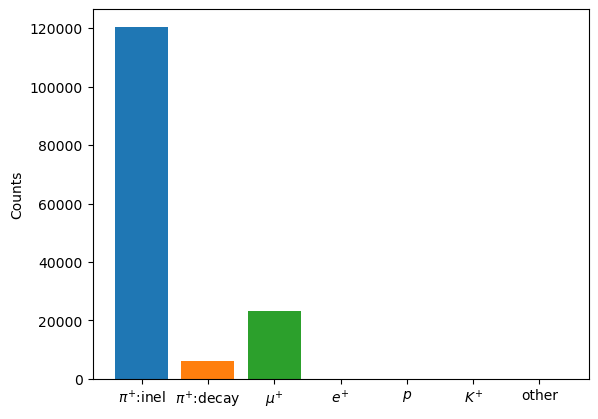

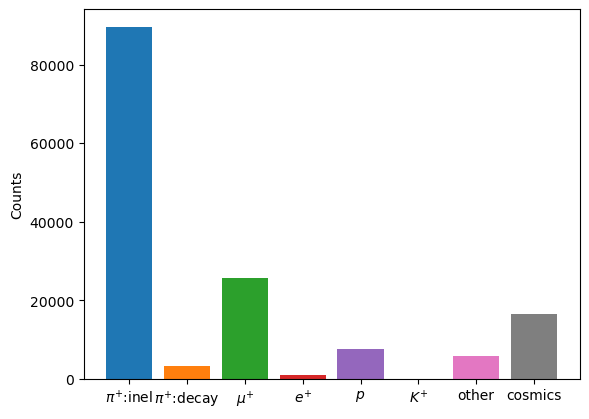

149791
23787
23787
116983
120369
89646


In [69]:
tags = Tags.GenerateTrueBeamParticleTags(bv_evts)
counts = ak.sum(tags.mask.values, axis=-1)
#counts = counts / np.sum(counts)  # Normalise counts to get percentages
plt.bar(tags.name.values, counts, color= tags.colour.values)
#plt.yscale("log")
plt.ylabel("Counts")
plt.show()

tags = Tags.GenerateBeamCandidateTags(bv_evts)
counts = ak.sum(tags.mask.values, axis=-1)
#counts = counts / np.sum(counts)  # Normalise counts to get percentages
plt.bar(tags.name.values, counts, color= tags.colour.values)
plt.ylabel("Counts")
plt.show()

print(ak.sum(ak.firsts(bv_evts.trueParticles.number)==1))
print(ak.sum(ak.firsts(bv_evts.trueParticlesBT.number)==1))
print(ak.sum(ak.firsts(bv_evts.trueParticlesBT.number)==ak.firsts(bv_evts.trueParticles.number)))
print(ak.sum(bv_evts.trueParticles.true_beam_endProcess == bv_evts.trueParticlesBT.beam_endProcess))
print(ak.sum(bv_evts.trueParticles.true_beam_endProcess == "pi+Inelastic"))
print(ak.sum(bv_evts.trueParticlesBT.beam_endProcess == "pi+Inelastic"))

In [70]:
purity = ak.sum(beam_selection.signal_mask(bv_evts)) / len(beam_selection.signal_mask(bv_evts))
print(f"Purity after BV selection: {purity:.2%}")

eff_bt = ak.sum(beam_selection.signal_mask(bv_evts)) / ak.sum(beam_selection.signal_mask(events))
eff_true = ak.sum(beam_selection.true_signal_mask(bv_evts)) / ak.sum(beam_selection.true_signal_mask(events))
print(f"Efficiency of the BV selection from backtracking: {eff_bt:.2%}")
print(f"Efficiency of the BV selection from truth info: {eff_true:.2%}")

# Relative efficiency

eff_bt = ak.sum(beam_selection.signal_mask(bv_evts)) / ak.sum(beam_selection.signal_mask(bi_evts))
eff_true = ak.sum(beam_selection.true_signal_mask(bv_evts)) / ak.sum(beam_selection.true_signal_mask(bi_evts)) 
print(f"Efficiency of the BI selection from backtracking: {eff_bt:.2%}")
print(f"Efficiency of the BI selection from truth info: {eff_true:.2%}")

Purity after BV selection: 62.01%
Efficiency of the BV selection from backtracking: 677.80%
Efficiency of the BV selection from truth info: 513.67%
Efficiency of the BI selection from backtracking: 100.00%
Efficiency of the BI selection from truth info: 87.63%


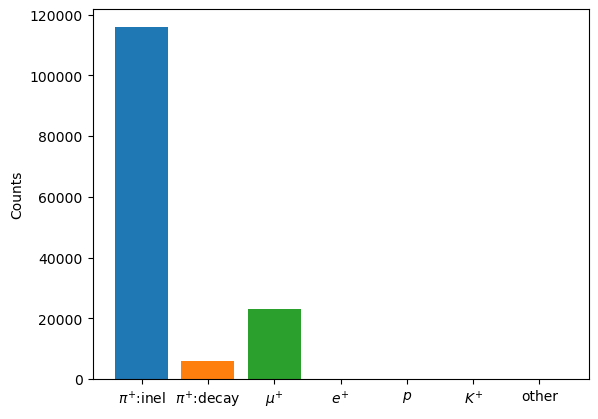

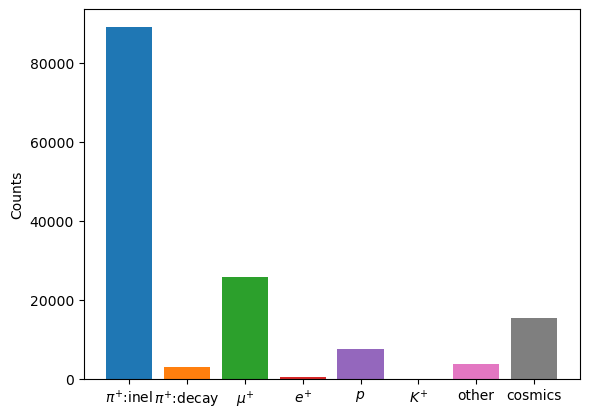

In [71]:
tags = Tags.GenerateTrueBeamParticleTags(track_evts)
counts = ak.sum(tags.mask.values, axis=-1)
#counts = counts / np.sum(counts)  # Normalise counts to get percentages
plt.bar(tags.name.values, counts, color= tags.colour.values)
plt.ylabel("Counts")
#plt.yscale("log")
plt.show()

tags = Tags.GenerateBeamCandidateTags(track_evts)
counts = ak.sum(tags.mask.values, axis=-1)
#counts = counts / np.sum(counts)  # Normalise counts to get percentages
plt.bar(tags.name.values, counts, color= tags.colour.values)
plt.ylabel("Counts")
plt.show()

In [72]:
purity = ak.sum(beam_selection.signal_mask(track_evts)) / len(beam_selection.signal_mask(track_evts))
print(f"Purity after BV selection: {purity:.2%}")

eff_bt = ak.sum(beam_selection.signal_mask(track_evts)) / ak.sum(beam_selection.signal_mask(events))
eff_true = ak.sum(beam_selection.true_signal_mask(track_evts)) / ak.sum(beam_selection.true_signal_mask(events))
print(f"Efficiency of the BV selection from backtracking: {eff_bt:.2%}")
print(f"Efficiency of the BV selection from truth info: {eff_true:.2%}")

# Relative efficiency

eff_bt = ak.sum(beam_selection.signal_mask(track_evts)) / ak.sum(beam_selection.signal_mask(bv_evts))
eff_true = ak.sum(beam_selection.true_signal_mask(track_evts)) / ak.sum(beam_selection.true_signal_mask(bv_evts))
print(f"Efficiency of the BI selection from backtracking: {eff_bt:.2%}")
print(f"Efficiency of the BI selection from truth info: {eff_true:.2%}")

Purity after BV selection: 63.55%
Efficiency of the BV selection from backtracking: 672.44%
Efficiency of the BV selection from truth info: 495.37%
Efficiency of the BI selection from backtracking: 99.21%
Efficiency of the BI selection from truth info: 96.44%


In [73]:
def run_beam_selection(evts):

    bi_mask = BeamParticleSelection.BeamTriggerSelection(evts, return_property=True)[0]
    evts.Filter([bi_mask], [bi_mask])
    bv_mask = evts.recoParticles.beam_particles > 0
    evts.Filter([bv_mask], [bv_mask])
    track_mask = evts.recoParticles.beam_pandora_tag == 13
    evts.Filter([track_mask], [track_mask])
    nhits_mask = ak.num(evts.recoParticles.n_hits) > 0
    evts.Filter([nhits_mask], [nhits_mask])
    return evts

In [74]:
evts = run_beam_selection(events)

In [75]:
evts.event_index

<Array [11, 23, 38, ... 181375, 181376, 181389] type='10984 * int64'>